In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pickle as pkl
import os
import time
from glob import glob
from tqdm import tqdm
from typing import Any

## Utility Functions

In [3]:
def load_pickle(filename:str) -> Any:
    '''Save the data in the pickle (pkl) format.'''
    with open(filename, 'rb') as handle:
        data = pkl.load(handle)
    return data

def save_pickle(filename: str, data: Any) -> None:
    '''Save the data in the pickle (pkl) format.'''
    with open(filename, 'wb') as handle:
        pkl.dump(data, handle, protocol=pkl.HIGHEST_PROTOCOL)

def is_valid_date_folder(name):
    return name.isdigit() and len(name) == 8

def get_valid_day_folders(base_path):
    return sorted([f for f in os.listdir(base_path) if is_valid_date_folder(f)])

def load_and_clean_day_data(base_path, day):
    print(f"--- Loading {day} ---")
    day_path = os.path.join(base_path, day, 'chunks_parquet_levels')
    parquet_files = sorted(glob(os.path.join(day_path, '*.parquet')))

    if not parquet_files:
        print(f"[!] No parquet files found for {day}")
        return pd.DataFrame()

    start_time = time.time()
    dfs = [pd.read_parquet(f) for f in parquet_files]
    df_day = pd.concat(dfs, ignore_index=True)

    # Clean column names
    df_day.columns = [col.strip() for col in df_day.columns]

    # Parse 'time' to datetime
    df_day['time'] = pd.to_datetime(df_day['time'])

    # Add trading day as separate column
    df_day['date'] = pd.to_datetime(day)

    print(f"Loaded {len(df_day):,} rows for {day} in {time.time() - start_time:.2f}s")
    return df_day

def save_cleaned_day(base_path, output_path, day):
    df_day = load_and_clean_day_data(base_path, day)
    if not df_day.empty:
        df_day.to_parquet(os.path.join(output_path, f"{day}_cleaned.parquet"), index=False)
        print(f"Saved cleaned data for {day}")

## Data Preprocessing

In [4]:
# Data Loading
base_path = '/mnt/storage_1_10T/citibank/egbs_data_02_25'
valid_days = get_valid_day_folders(base_path)
days = valid_days[:1]
all_days_data = []

for day in tqdm(days):
    print(f"Processing {day}")
    df_raw = load_and_clean_day_data(base_path, day)
    if not df_raw.empty:
        all_days_data.append(df_raw)

df_all = pd.concat(all_days_data, ignore_index=True)
print(f"\nLoaded total of {len(df_all):,} rows across {len(valid_days)} days.")

# Data Cleaning
df_clean = df_all.copy()
df_clean = df_clean.dropna()

missing_rows = df_clean.isnull().any(axis=1).sum()
total_rows = len(df_clean)

# Symbol Filtering
SYMBOLS_TO_EXCLUDE = ['FGBLM5', 'CONFH5']
initial_syms = df_clean['sym'].nunique()
df_filtered = df_clean[~df_clean['sym'].isin(SYMBOLS_TO_EXCLUDE)].copy()

  0%|          | 0/1 [00:00<?, ?it/s]

Processing 20250212
--- Loading 20250212 ---


100%|██████████| 1/1 [00:22<00:00, 22.10s/it]

Loaded 17,000,000 rows for 20250212 in 21.96s

Loaded total of 17,000,000 rows across 10 days.


## Features Engineering

In [5]:
def compute_microstructure_features(df):
    
    # Midprice
    df["mid_price"] = (df["L1_bid_price"] + df["L1_ask_price"]) / 2

    # Weighted MidPrice (WMP)
    df["weighted_mid_price"] = (df["L1_bid_price"] * df["L1_ask_size"] + df["L1_ask_price"] * df["L1_bid_size"]) / (
        df["L1_bid_size"] + df["L1_ask_size"]
    )

    # Spread
    df["spread"] = df["L1_ask_price"] - df["L1_bid_price"]

    # Order Book Imbalance (OBI) 
    for i in range(1, 11):
        bid = f"L{i}_bid_size"
        ask = f"L{i}_ask_size"
        df[f"obi_L{i}"] = (df[bid] - df[ask]) / (df[bid] + df[ask])

    # Depth imbalance (L1 to L10)
    bid_cols = [f"L{i}_bid_size" for i in range(1, 11)]
    ask_cols = [f"L{i}_ask_size" for i in range(1, 11)]

    df["cum_bid_vol_10"] = df[bid_cols].sum(axis=1)
    df["cum_ask_vol_10"] = df[ask_cols].sum(axis=1)
    df["depth_imbalance_10"] = (df["cum_bid_vol_10"] - df["cum_ask_vol_10"]) / (
        df["cum_bid_vol_10"] + df["cum_ask_vol_10"]
    )

    # Liquidity metrics
    df["liquidity_impact_bid"] = df["L1_bid_price"] - df["L2_bid_price"]
    df["liquidity_impact_ask"] = df["L2_ask_price"] - df["L1_ask_price"]
    df["bid_price_slope"] = (df["L1_bid_price"] - df["L5_bid_price"]) / 4
    df["ask_price_slope"] = (df["L5_ask_price"] - df["L1_ask_price"]) / 4

    # Order Flow Imbalance (OFI)
    df["ofi"] = df["L1_bid_size"].diff() - df["L1_ask_size"].diff()

    # Simple Moving Average (SMA)
    df["sma_10"] = df["weighted_mid_price"].rolling(window=10).mean()
    df["sma_100"] = df["weighted_mid_price"].rolling(window=100).mean()
    df["sma_1000"] = df["weighted_mid_price"].rolling(window=1000).mean()

    # Exponential Moving Average (EMA)
    df["ema_10"] = df["weighted_mid_price"].ewm(span=10, adjust=False).mean()
    df["ema_100"] = df["weighted_mid_price"].ewm(span=100, adjust=False).mean()
    df["ema_1000"] = df["weighted_mid_price"].ewm(span=1000, adjust=False).mean()

    # Momentum
    df["momentum_10"] = df["weighted_mid_price"] - df["weighted_mid_price"].shift(10)
    df["momentum_100"] = df["weighted_mid_price"] - df["weighted_mid_price"].shift(100)
    df["momentum_1000"] = df["weighted_mid_price"] - df["weighted_mid_price"].shift(1000)

    # Order Flow Imbalance (OFI)
    #df["ofi"] = df["L1_bid_size"].diff() - df["L1_ask_size"].diff()

    # Returns
    df["return_1"] = df["weighted_mid_price"].pct_change()
    df["return_5"] = df["weighted_mid_price"].pct_change(5)
    df["log_return_1"] = np.log(df["weighted_mid_price"] / df["weighted_mid_price"].shift(1))
    df["log_return_5"] = np.log(df["weighted_mid_price"] / df["weighted_mid_price"].shift(5))
    
    # Relative Strength Index (RSI)
    def compute_rsi(df, period=14):
        delta = df["weighted_mid_price"].diff()
        gain = delta.clip(lower=0)
        loss = -delta.clip(upper=0)

        # Wilder's method using EMA
        avg_gain = gain.ewm(alpha=1/period, min_periods=period, adjust=False).mean()
        avg_loss = loss.ewm(alpha=1/period, min_periods=period, adjust=False).mean()

        rs = avg_gain / avg_loss

        df[f"rsi_{period}"] = 100 - (100 / (1 + rs))
        df[f"rsi_signal_{period}"] = np.where(df[f"rsi_{period}"] > 70, -1, np.where(df[f"rsi_{period}"] < 30, 1, 0))

        return df

    df = compute_rsi(df, period=10)
    df = compute_rsi(df, period=20)
    df = compute_rsi(df, period=100)
    df = compute_rsi(df, period=1000)

    # Bollinger Bands
    def compute_bollinger_bands(df: pd.DataFrame, window: int = 20) -> pd.DataFrame:
        """Compute Bollinger Bands for the given DataFrame.

        Args:
            df (pd.DataFrame): DataFrame containing the 'mid_price' column.
            window (int): The rolling window size for the Bollinger Bands.

        Returns:
            pd.DataFrame: DataFrame with Bollinger Bands and signals added.
        """
        rolling_mean = df["weighted_mid_price"].rolling(window=window).mean()
        rolling_std = df["weighted_mid_price"].rolling(window=window).std()

        df[f"bollinger_upper_{window}"] = rolling_mean + 2 * rolling_std
        df[f"bollinger_lower_{window}"] = rolling_mean - 2 * rolling_std
        df[f"band_width_{window}"] = df[f"bollinger_upper_{window}"] - df[f"bollinger_lower_{window}"]
        df[f"bollinger_signal_{window}"] = np.where(df["weighted_mid_price"] > df[f"bollinger_upper_{window}"], -1, 
                                           np.where(df["weighted_mid_price"] < df[f"bollinger_lower_{window}"], 1, 0))
        return df

    df = compute_bollinger_bands(df, window=10)
    df = compute_bollinger_bands(df, window=20)
    df = compute_bollinger_bands(df, window=100)
    df = compute_bollinger_bands(df, window=1000)

    
    # Time encoding
    if pd.api.types.is_datetime64_any_dtype(df["time"]):
        df["seconds_since_midnight"] = (
            df["time"].dt.hour * 3600
            + df["time"].dt.minute * 60
            + df["time"].dt.second
            + df["time"].dt.microsecond / 1e6
        )
    
    return df

In [6]:
df_filtered.columns

Index(['time', 'sym', 'exch_time', 'exchange', 'first_sequence_number',
       'last_sequence_number', 'first_sym_sequence', 'last_sym_sequence',
       'first_time', 'first_exch_time', 'event_id', 'L1_bid_price',
       'L1_bid_size', 'L1_bid_no', 'L1_ask_price', 'L1_ask_size', 'L1_ask_no',
       'L2_bid_price', 'L2_bid_size', 'L2_bid_no', 'L2_ask_price',
       'L2_ask_size', 'L2_ask_no', 'L3_bid_price', 'L3_bid_size', 'L3_bid_no',
       'L3_ask_price', 'L3_ask_size', 'L3_ask_no', 'L4_bid_price',
       'L4_bid_size', 'L4_bid_no', 'L4_ask_price', 'L4_ask_size', 'L4_ask_no',
       'L5_bid_price', 'L5_bid_size', 'L5_bid_no', 'L5_ask_price',
       'L5_ask_size', 'L5_ask_no', 'L6_bid_price', 'L6_bid_size', 'L6_bid_no',
       'L6_ask_price', 'L6_ask_size', 'L6_ask_no', 'L7_bid_price',
       'L7_bid_size', 'L7_bid_no', 'L7_ask_price', 'L7_ask_size', 'L7_ask_no',
       'L8_bid_price', 'L8_bid_size', 'L8_bid_no', 'L8_ask_price',
       'L8_ask_size', 'L8_ask_no', 'L9_bid_price', 'L9_b

In [6]:
#df = compute_microstructure_features(df_filtered.copy())

In [ ]:
sym_dfs = {}
for sym, sym_df in tqdm(df_filtered.groupby('sym'), total=df_filtered['sym'].nunique(), desc="Computing microstructure features"):
    print(f"    Computed features for {sym}")
    sym_df = compute_microstructure_features(sym_df.copy())
    sym_dfs[sym] = sym_df
    print(f"    Dataset shape: {sym_df.shape}\n")

Computing microstructure features:  12%|█▎        | 1/8 [00:46<05:28, 46.93s/it]

    Computed features for FBONH5
    Dataset shape: (42905, 131)

    Computed features for FBTPH5


Computing microstructure features:  25%|██▌       | 2/8 [00:48<02:00, 20.02s/it]

    Dataset shape: (1624107, 131)

    Computed features for FBTSH5


Computing microstructure features:  38%|███▊      | 3/8 [00:48<00:55, 11.01s/it]

...

    Dataset shape: (643464, 131)

    Computed features for FGBXH5


Computing microstructure features:  88%|████████▊ | 7/8 [01:42<00:15, 15.15s/it]

    Dataset shape: (4146644, 131)

    Computed features for FOATH5


Computing microstructure features: 100%|██████████| 8/8 [02:01<00:00, 15.23s/it]

    Dataset shape: (2700417, 131)



### Weighted Mid-Price (WMP)

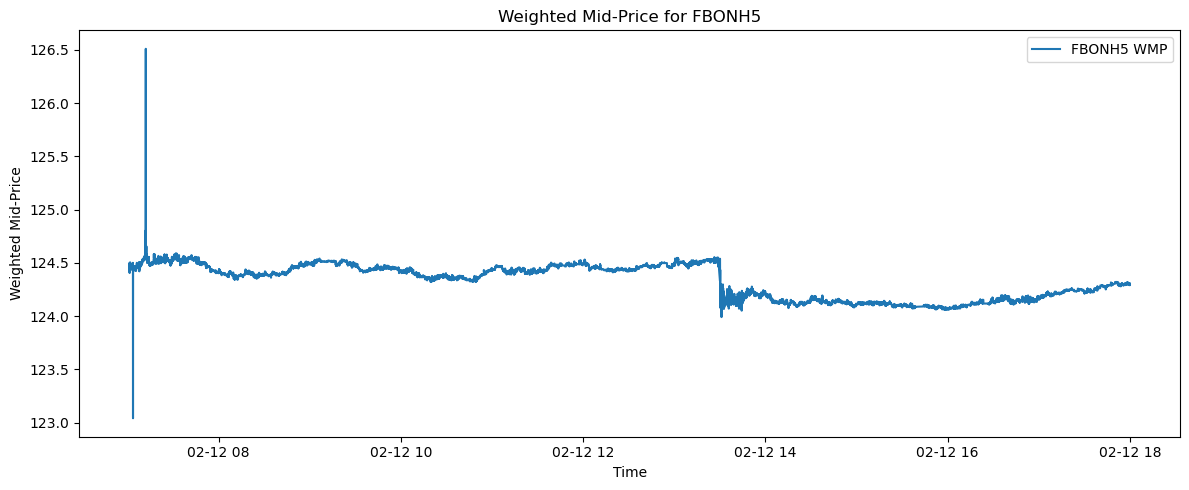

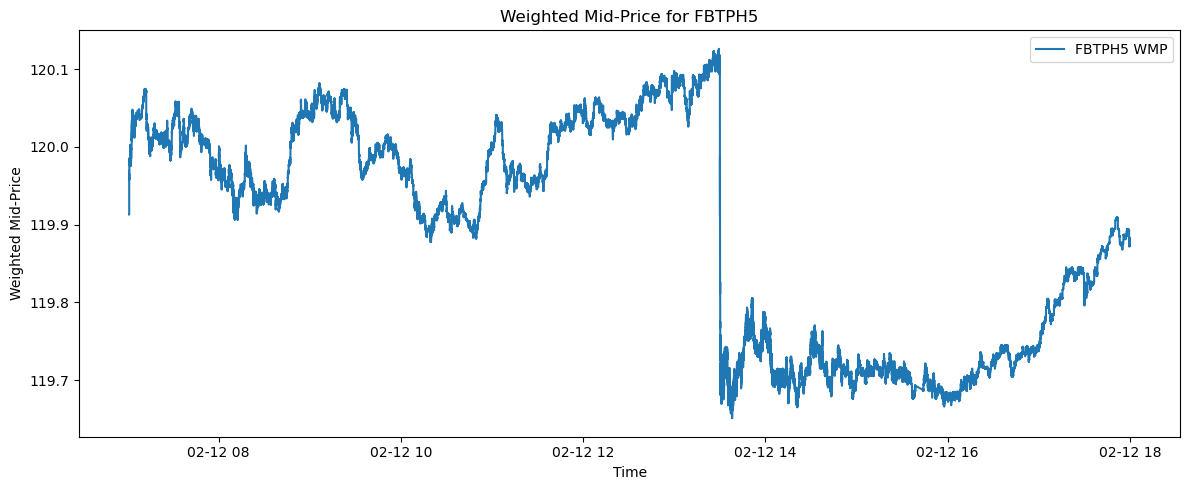

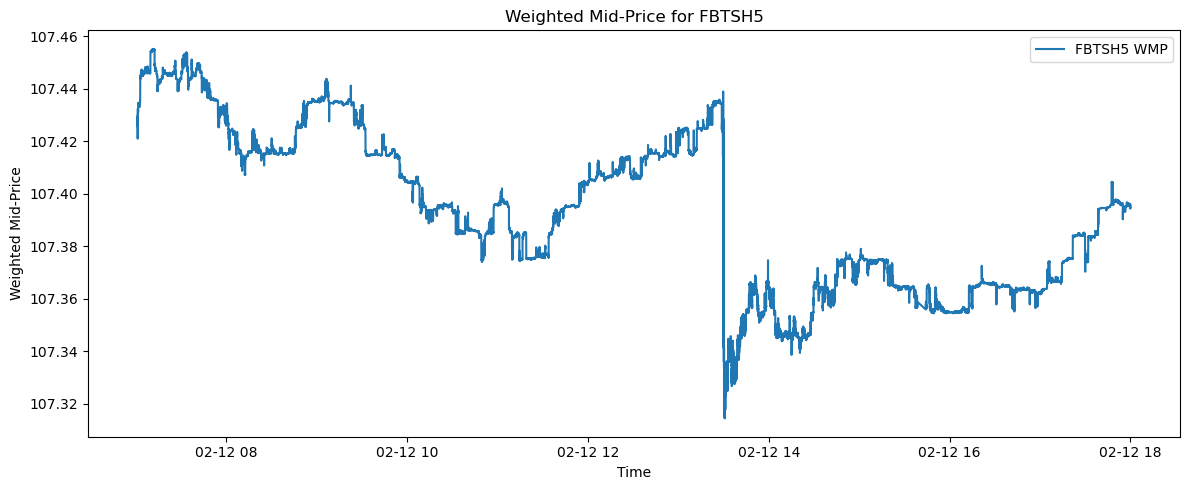

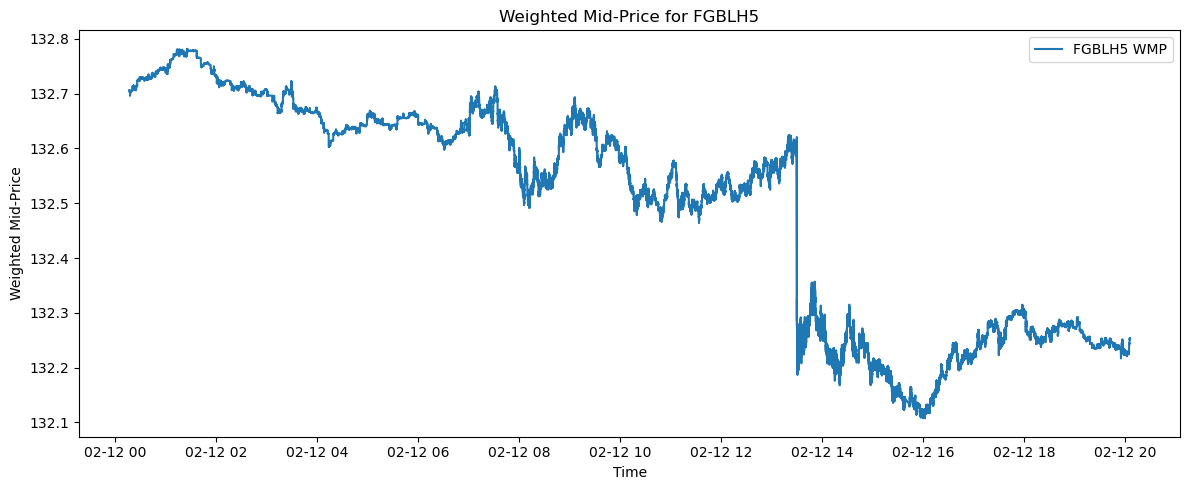

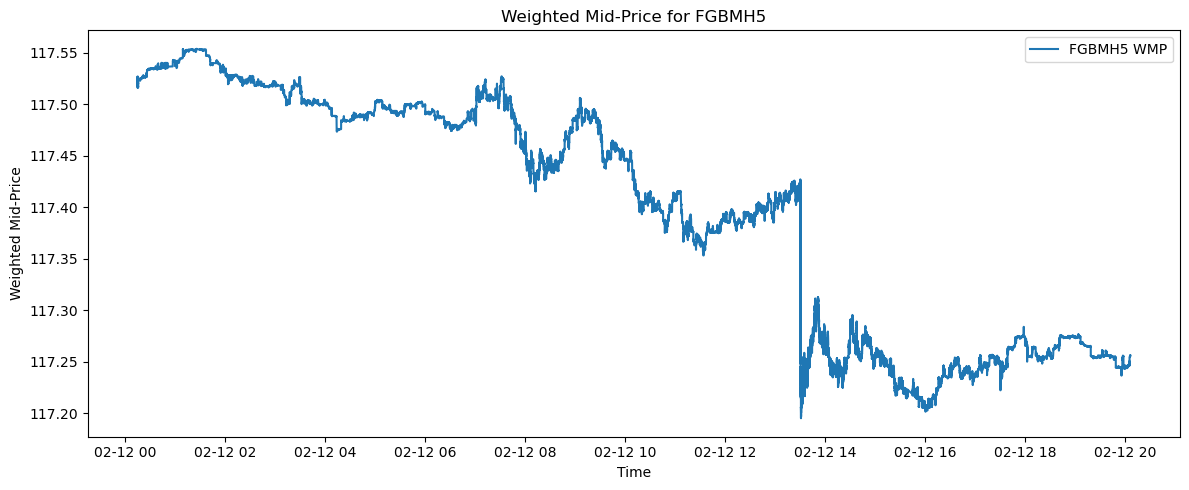

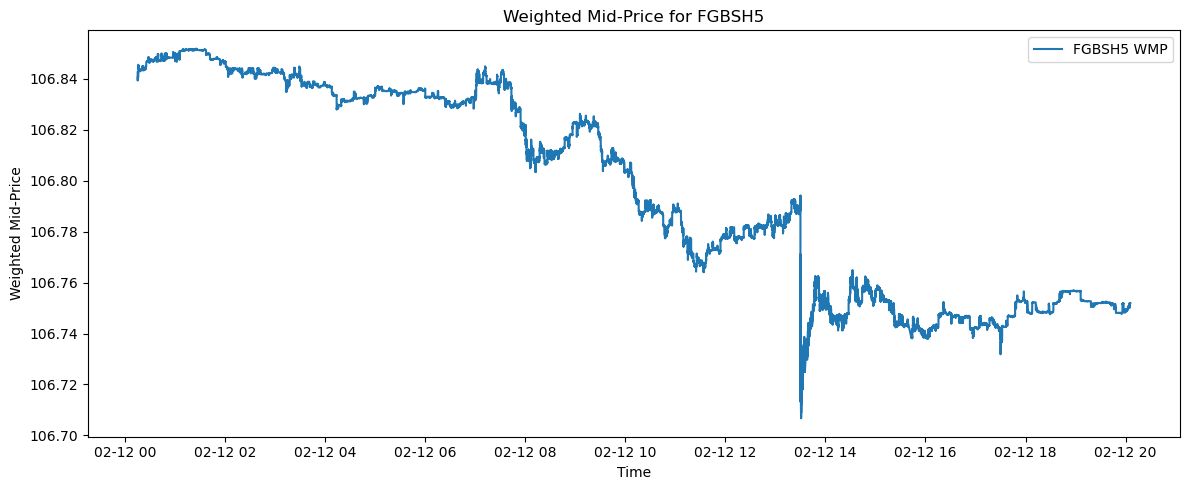

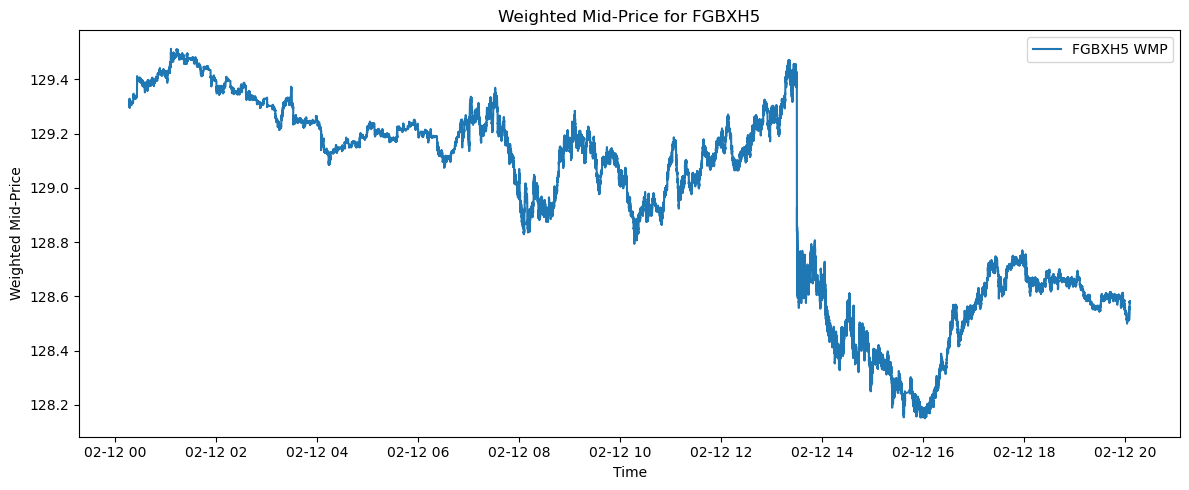

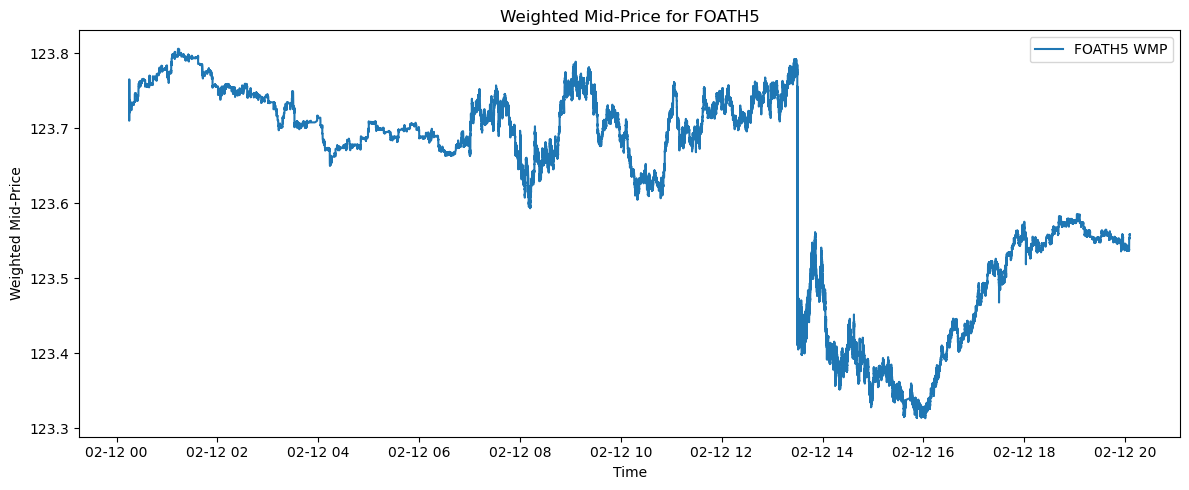

In [22]:
for sym, df_sym in sym_dfs.items():
    plt.figure(figsize=(12, 5))
    plt.plot(df_sym['time'], df_sym['weighted_mid_price'], label=f'{sym} WMP')
    plt.title(f'Weighted Mid-Price for {sym}')
    plt.xlabel('Time')
    plt.ylabel('Weighted Mid-Price')
    plt.legend()
    plt.tight_layout()
    plt.show()

### Moving average WMP

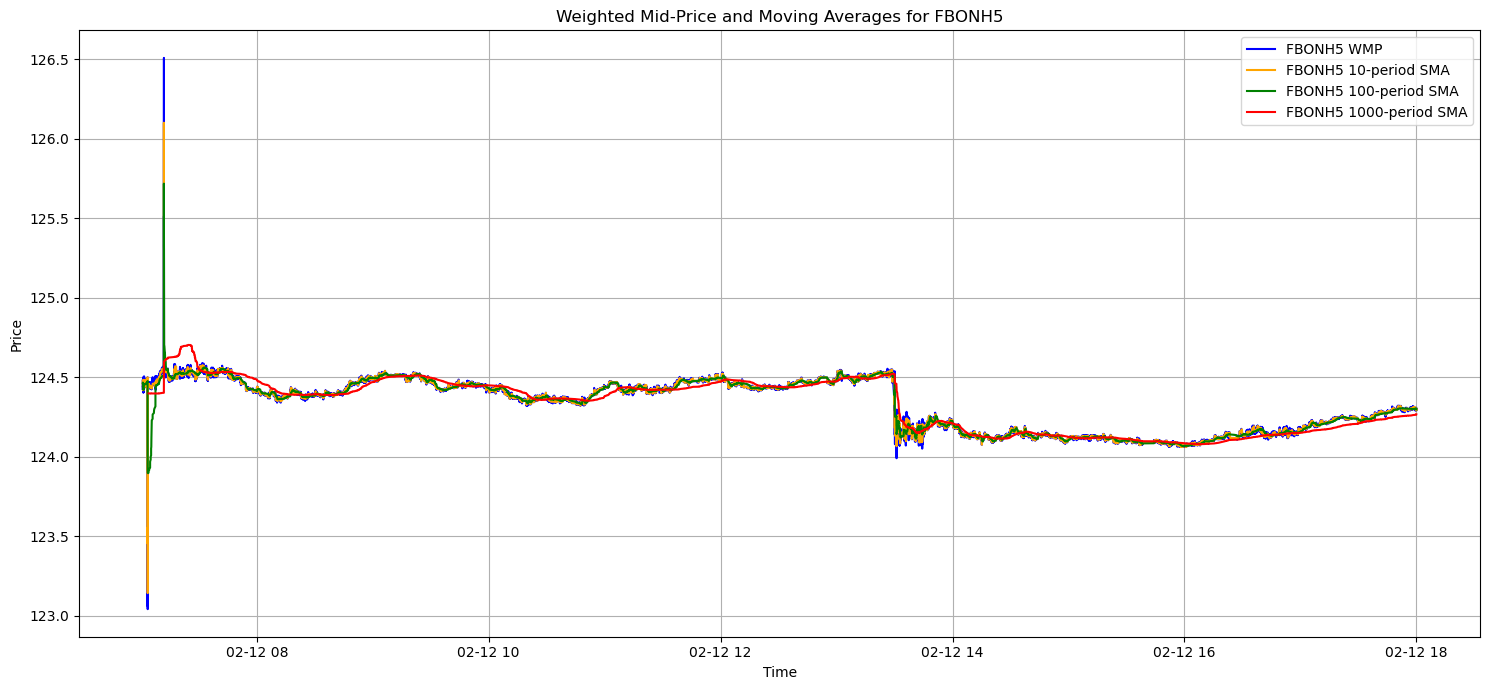

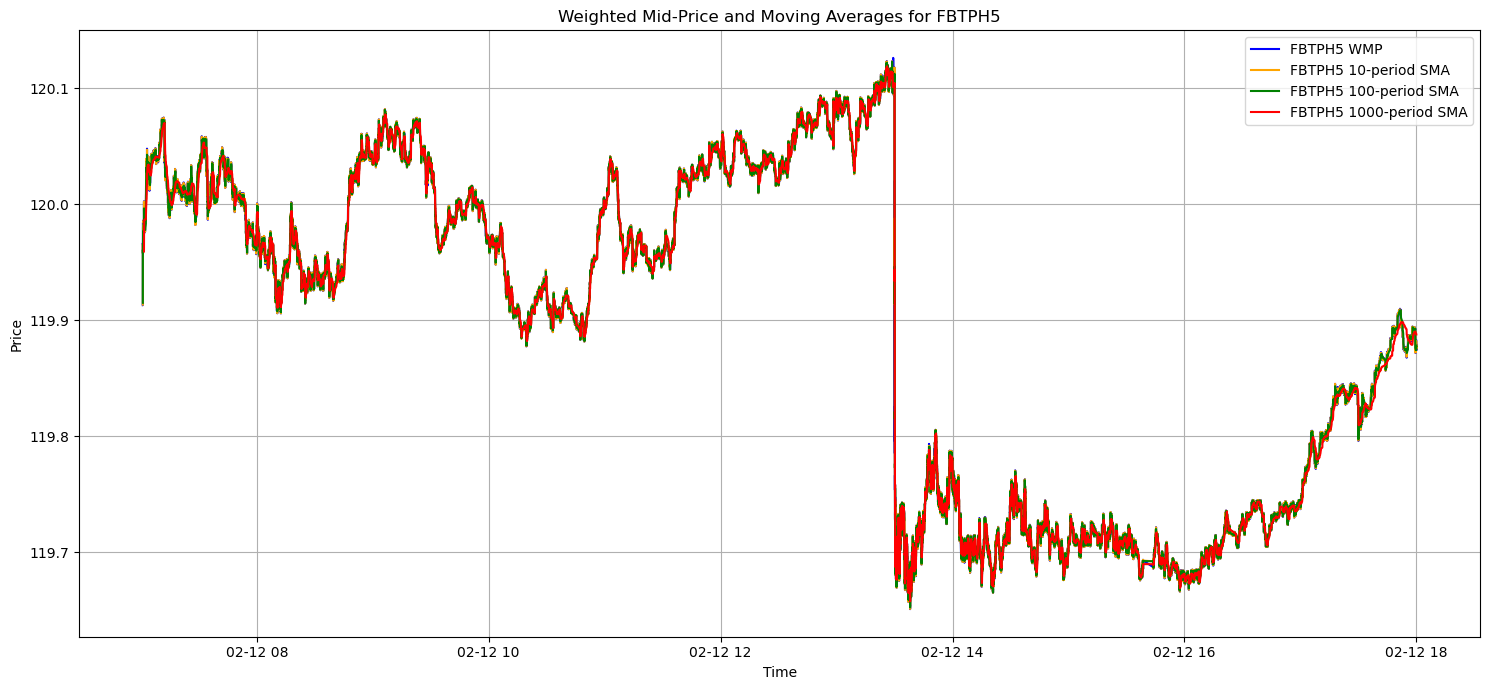

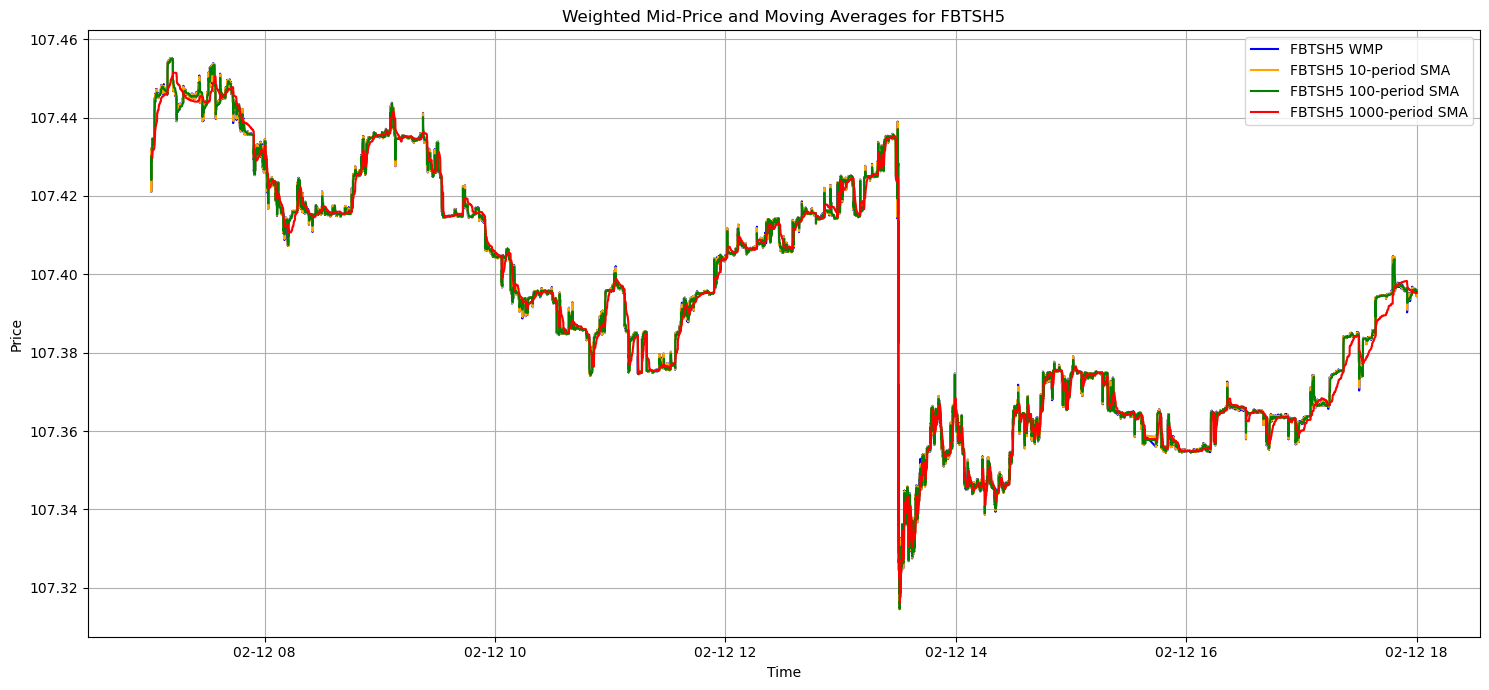

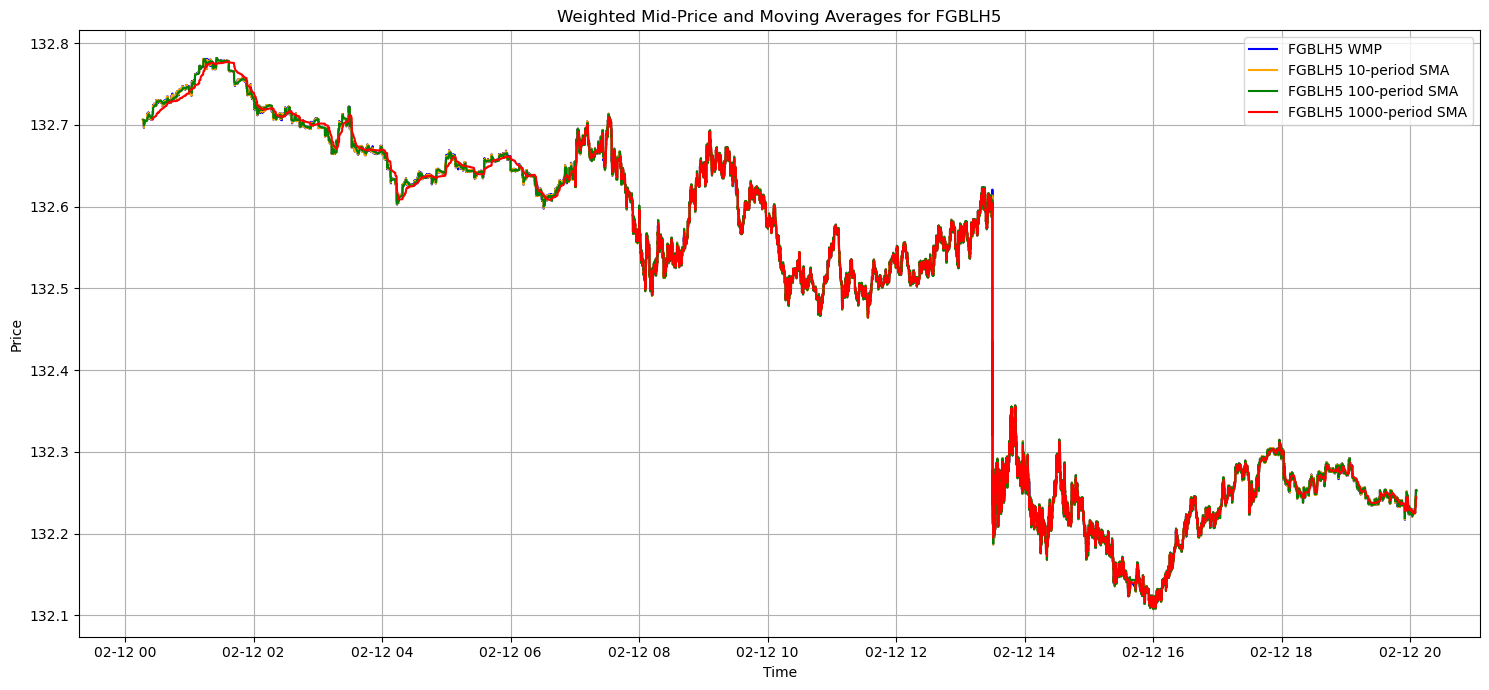

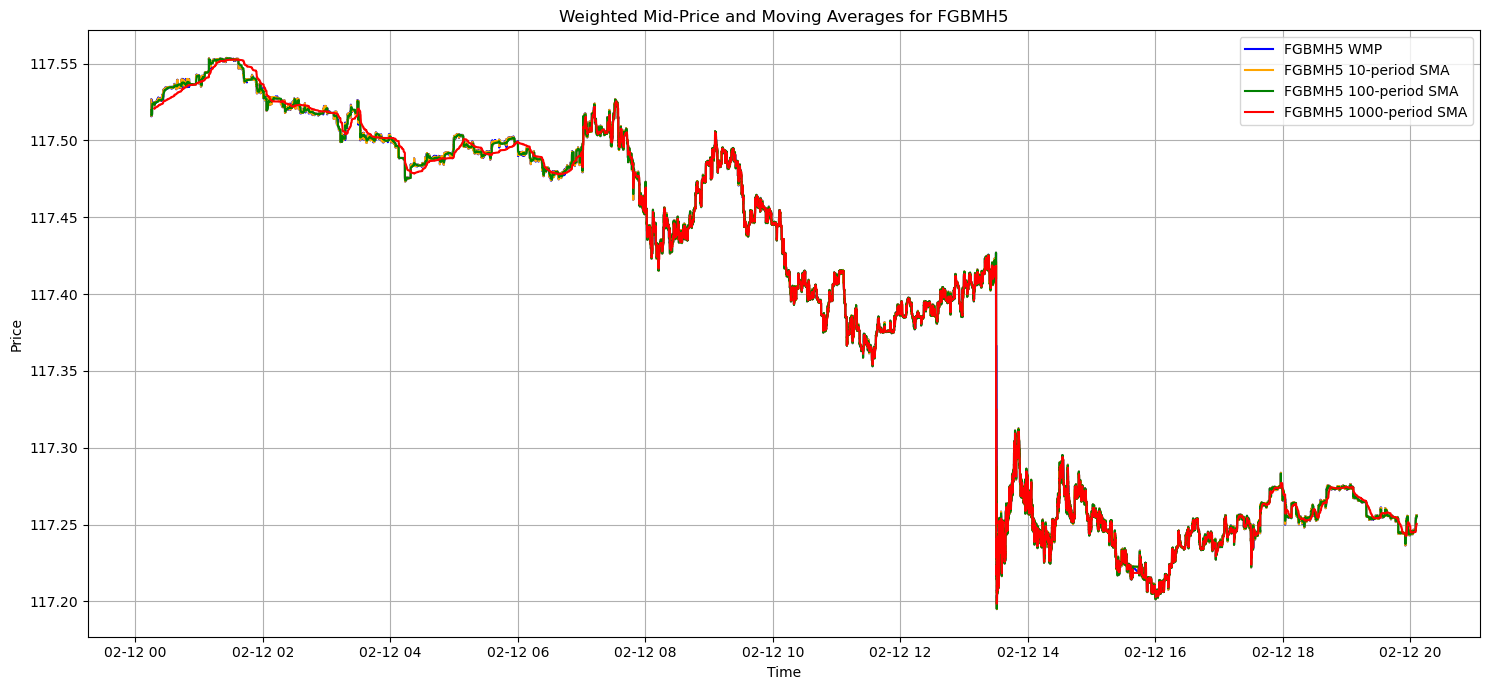

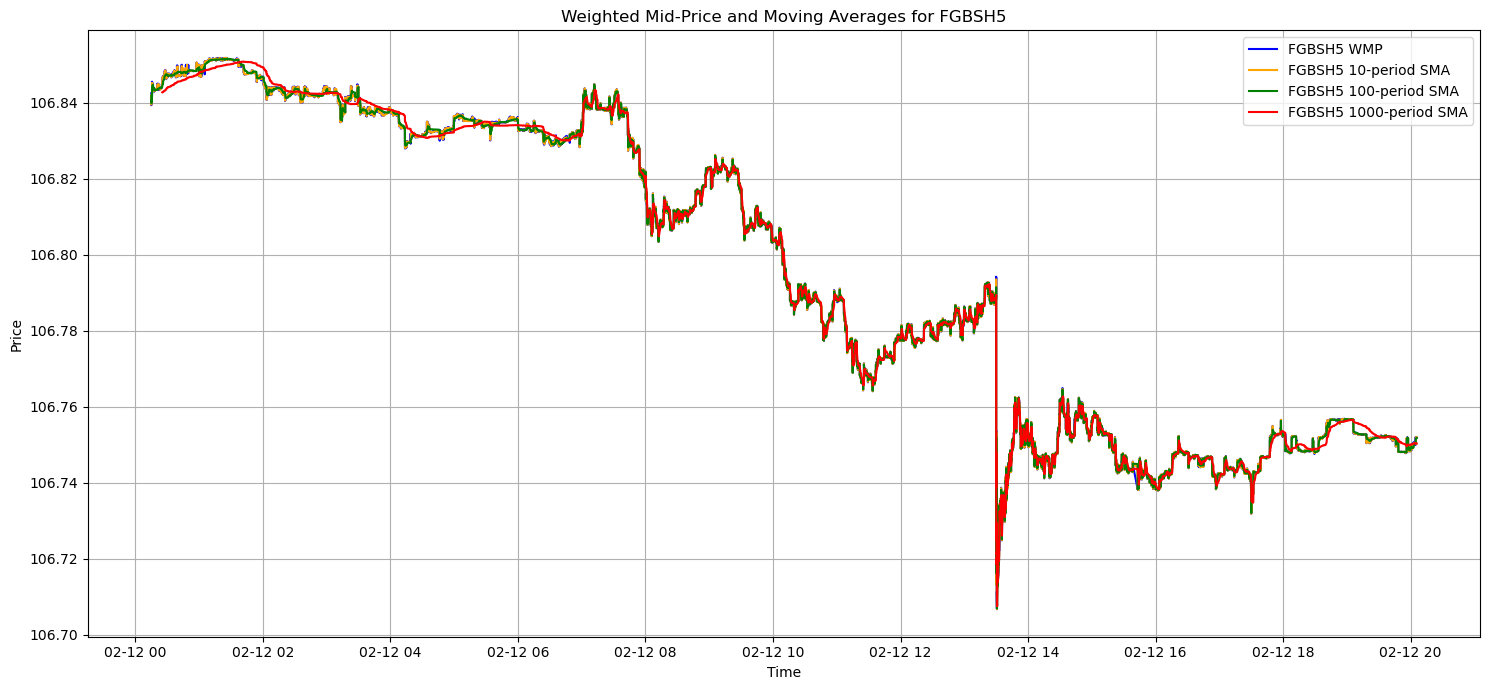

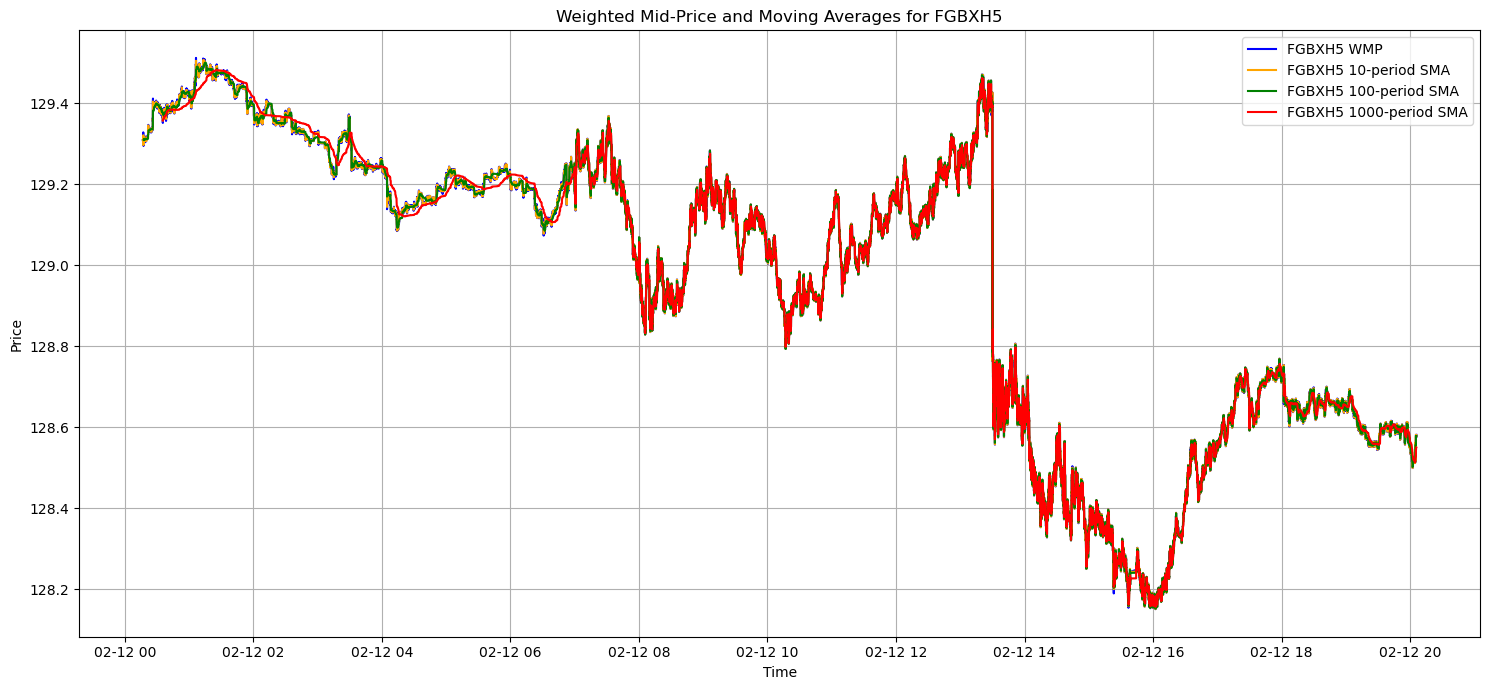

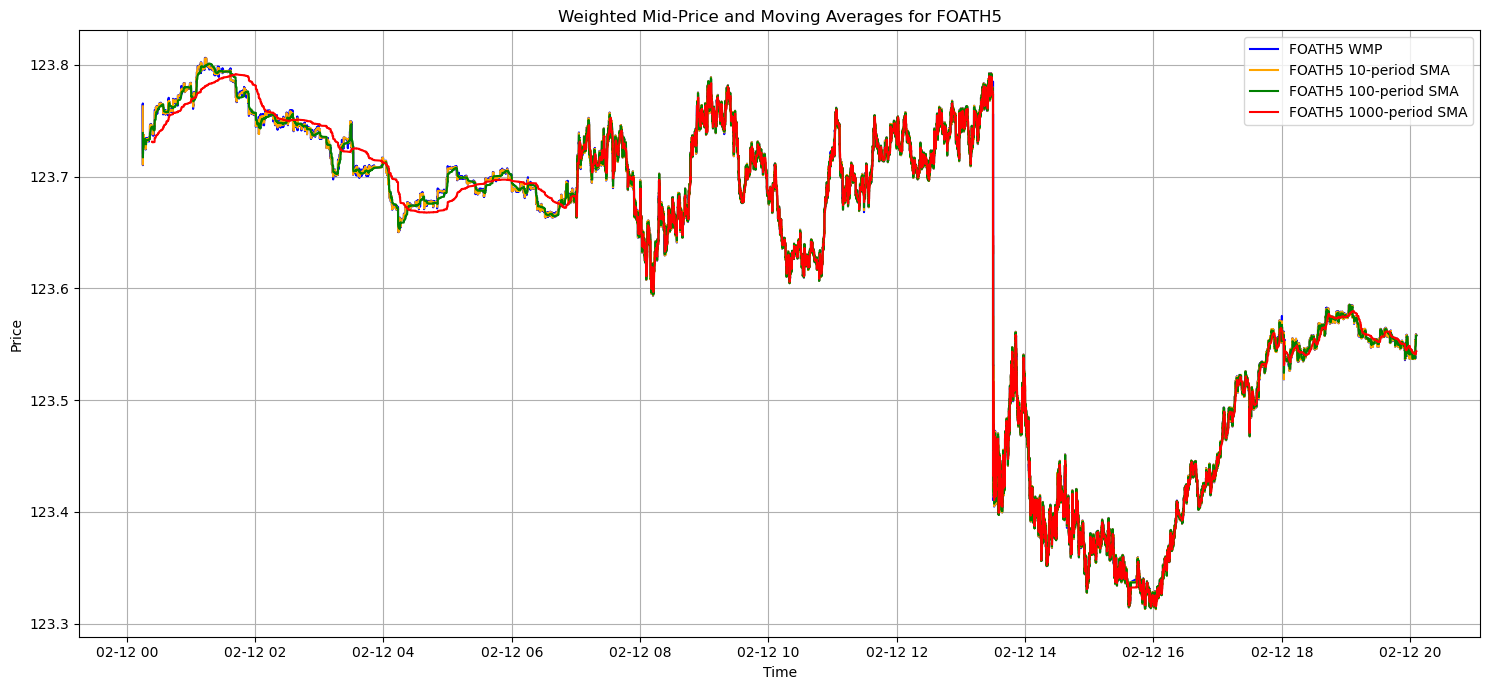

In [23]:
for sym, df_sym in sym_dfs.items():
    plt.figure(figsize=(15, 7)) 

    # Plot the original weighted mid-price
    plt.plot(df_sym['time'], df_sym['weighted_mid_price'], label=f'{sym} WMP', color='blue')

    # Plot the moving averages
    plt.plot(df_sym['time'], df_sym['sma_10'], label=f'{sym} 10-period SMA', color='orange')
    plt.plot(df_sym['time'], df_sym['sma_100'], label=f'{sym} 100-period SMA', color='green')
    plt.plot(df_sym['time'], df_sym['sma_1000'], label=f'{sym} 1000-period SMA', color='red')

    plt.title(f'Weighted Mid-Price and Moving Averages for {sym}')
    plt.xlabel('Time')
    plt.ylabel('Price')
    plt.legend()
    plt.grid(True) 
    plt.tight_layout()
    plt.show()

### Exponential Moving Average

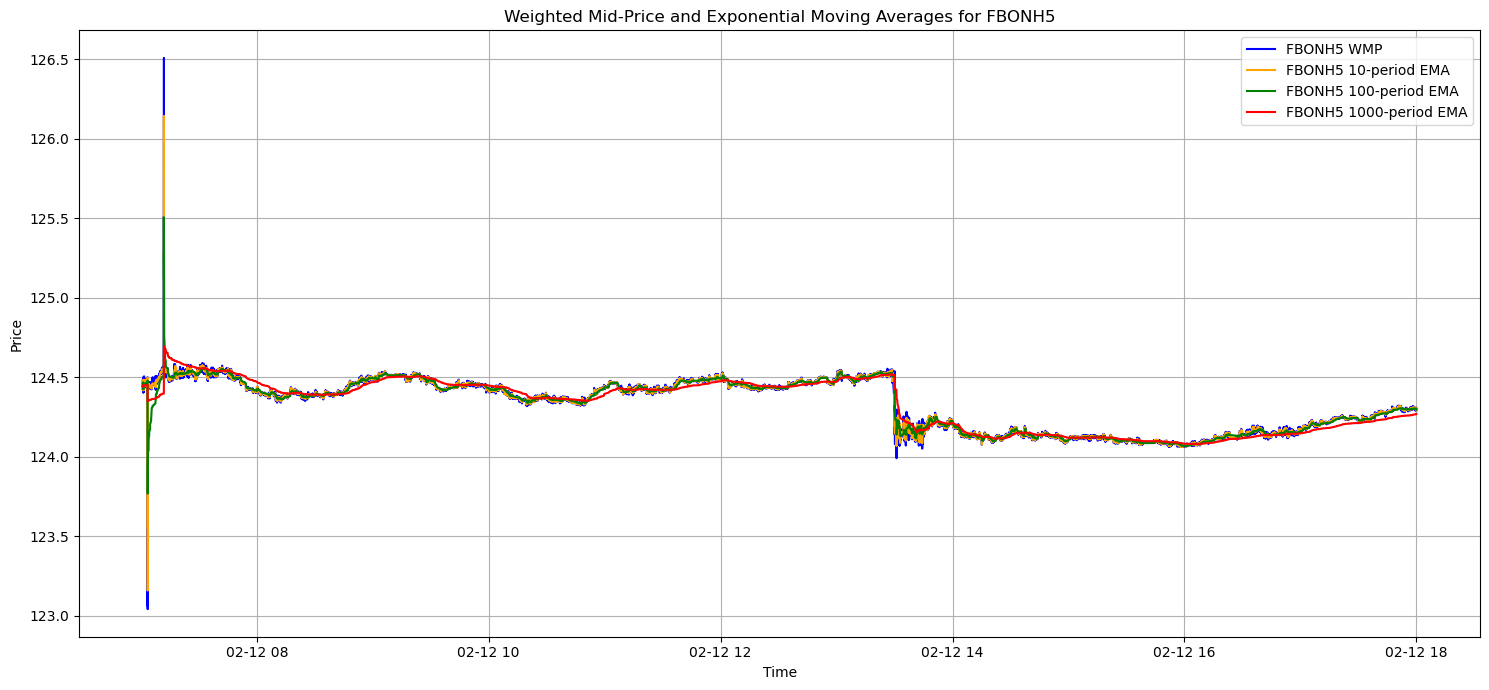

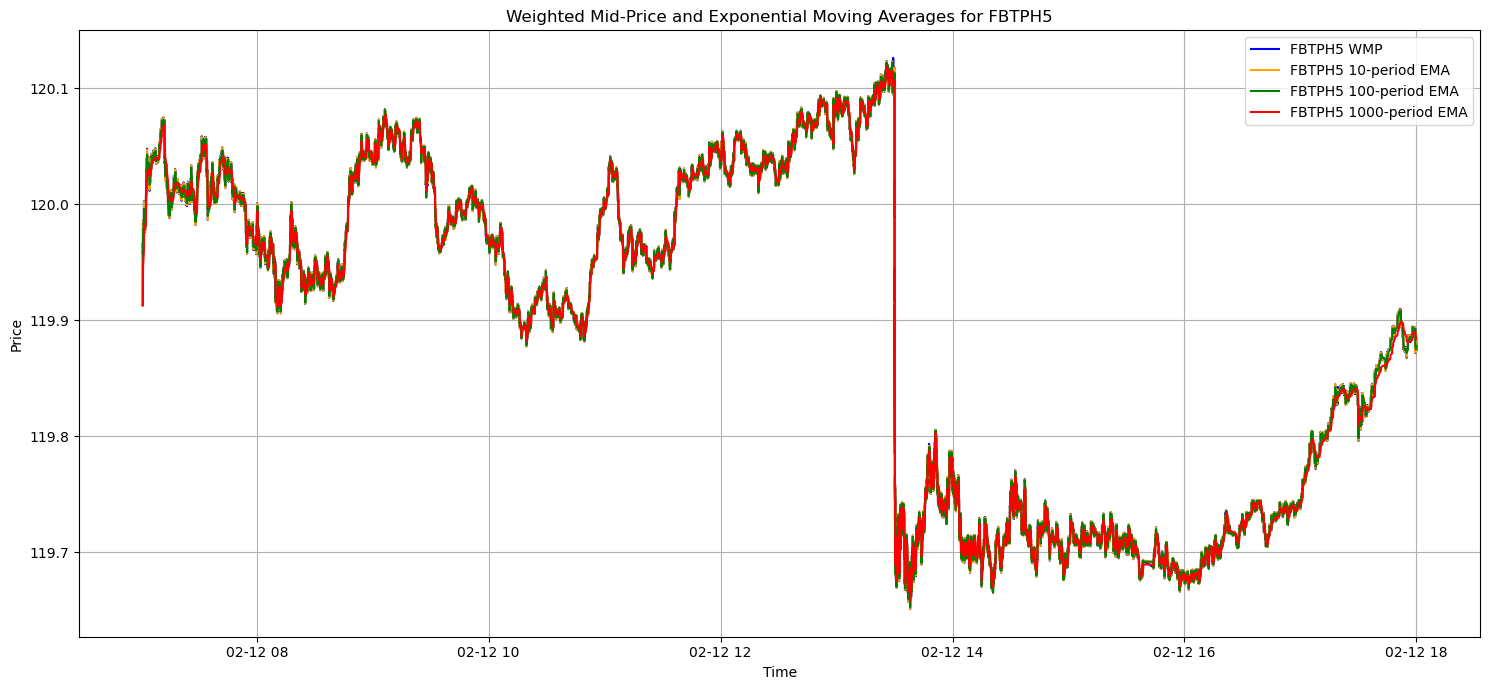

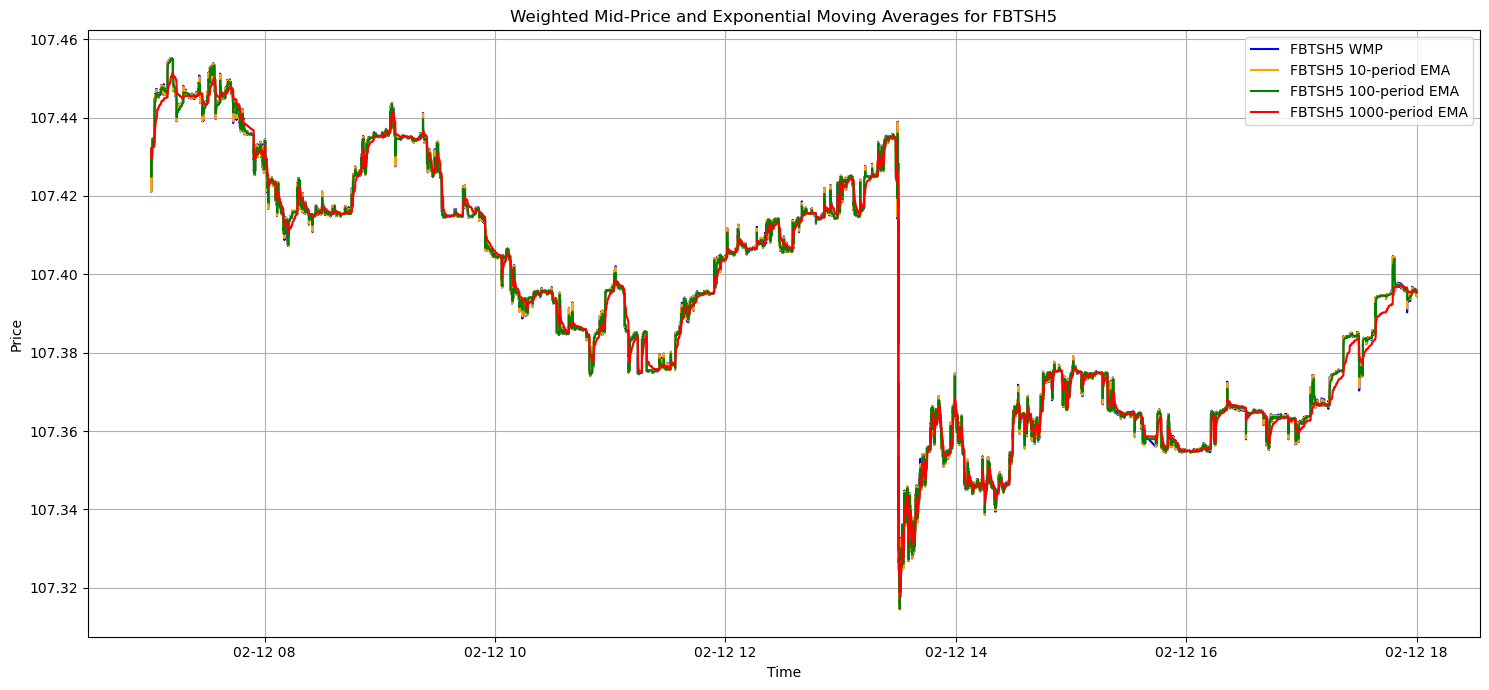

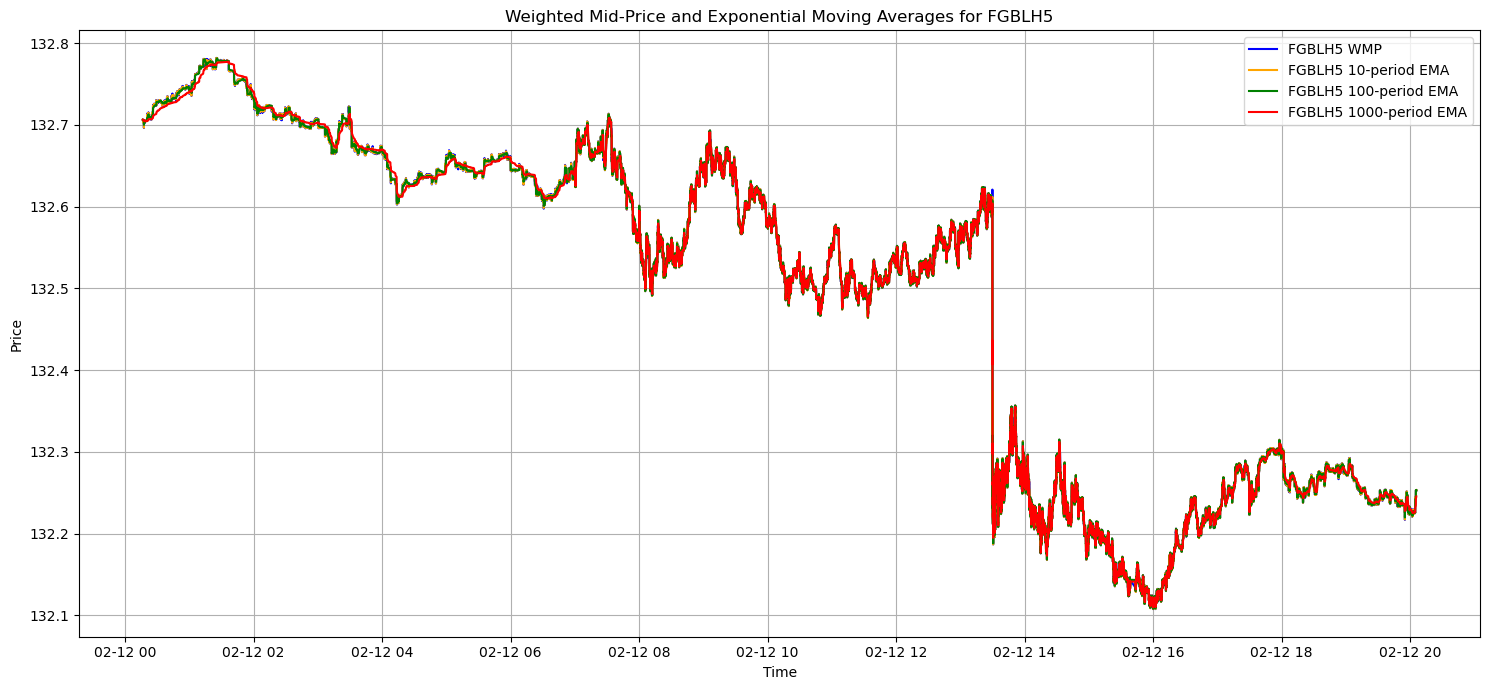

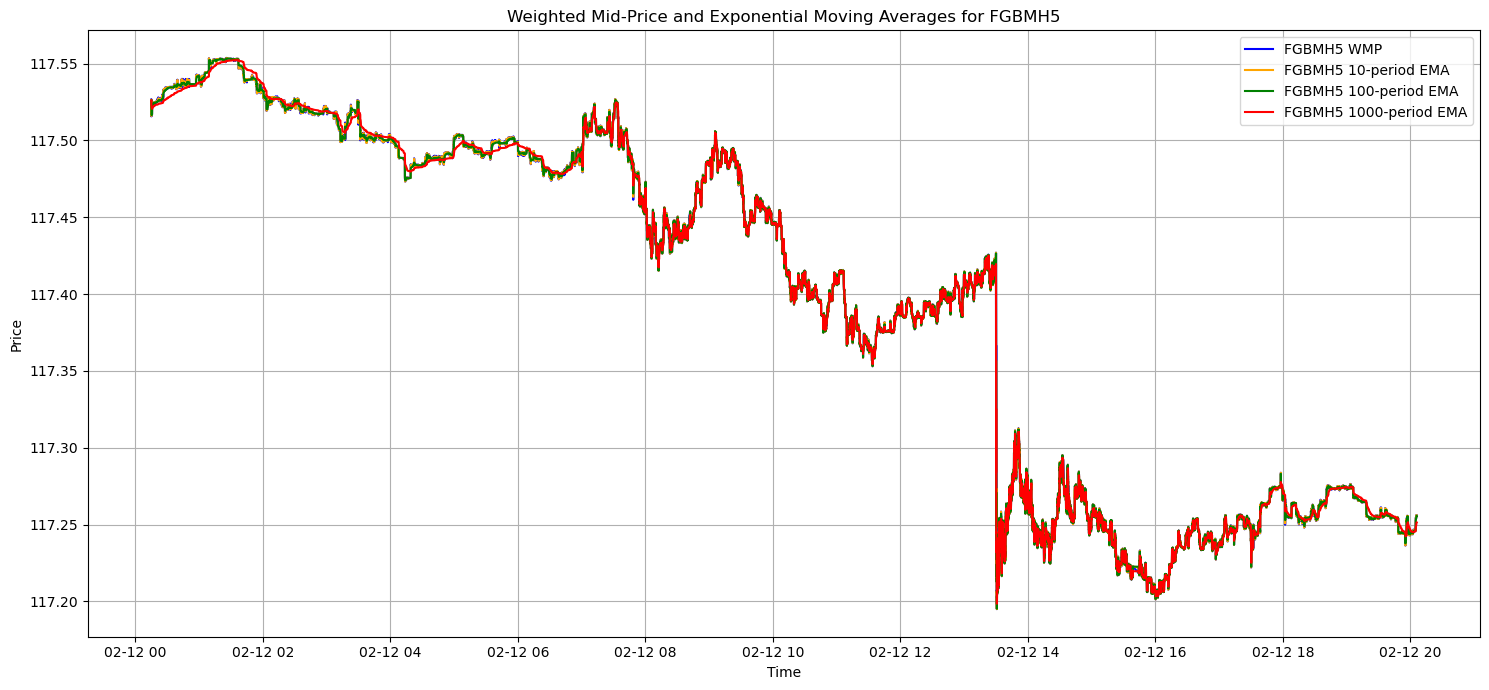

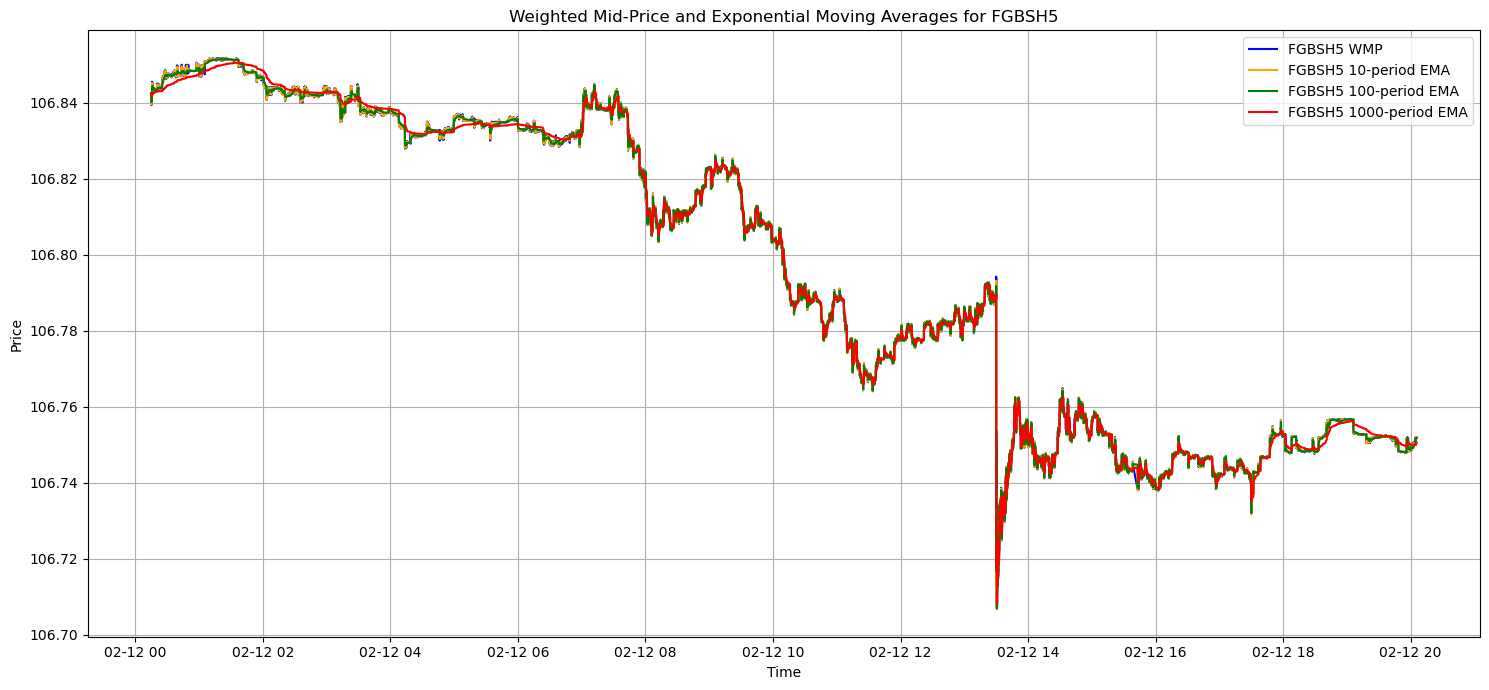

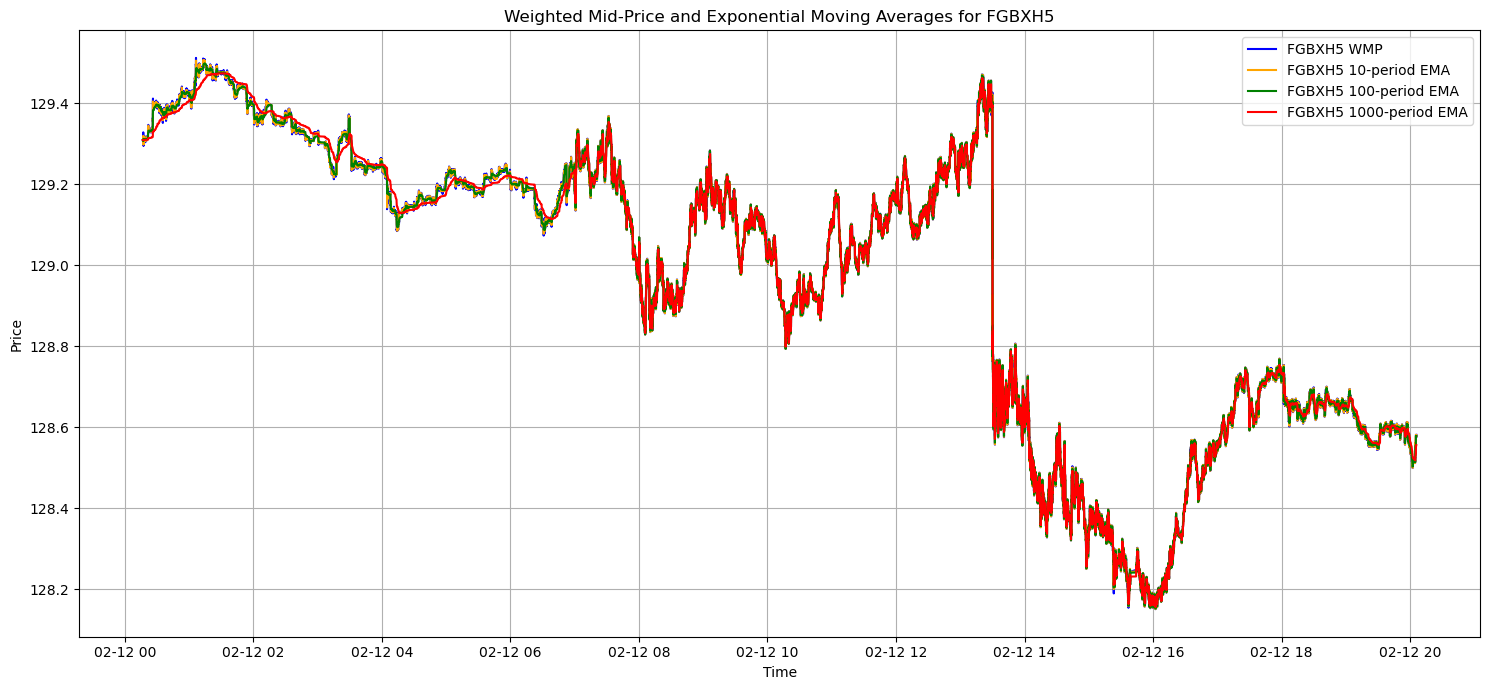

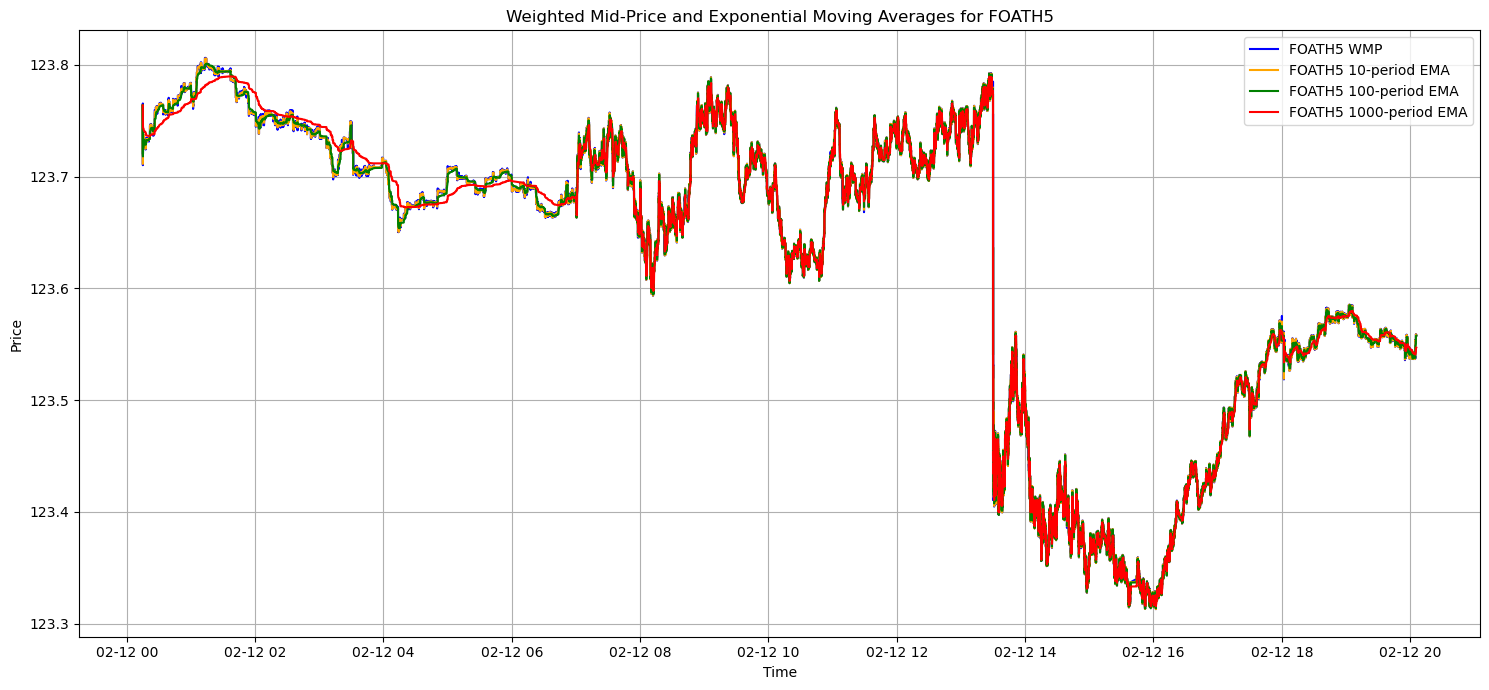

In [24]:
for sym, df_sym in sym_dfs.items():
    plt.figure(figsize=(15, 7)) 

    plt.plot(df_sym['time'], df_sym['weighted_mid_price'], label=f'{sym} WMP', color='blue')

    # Plot the exponential moving averages
    plt.plot(df_sym['time'], df_sym['ema_10'], label=f'{sym} 10-period EMA', color='orange')
    plt.plot(df_sym['time'], df_sym['ema_100'], label=f'{sym} 100-period EMA', color='green')
    plt.plot(df_sym['time'], df_sym['ema_1000'], label=f'{sym} 1000-period EMA', color='red')

    plt.title(f'Weighted Mid-Price and Exponential Moving Averages for {sym}')
    plt.xlabel('Time')
    plt.ylabel('Price')
    plt.legend()
    plt.grid(True) 
    plt.tight_layout()
    plt.show()

### Momentum

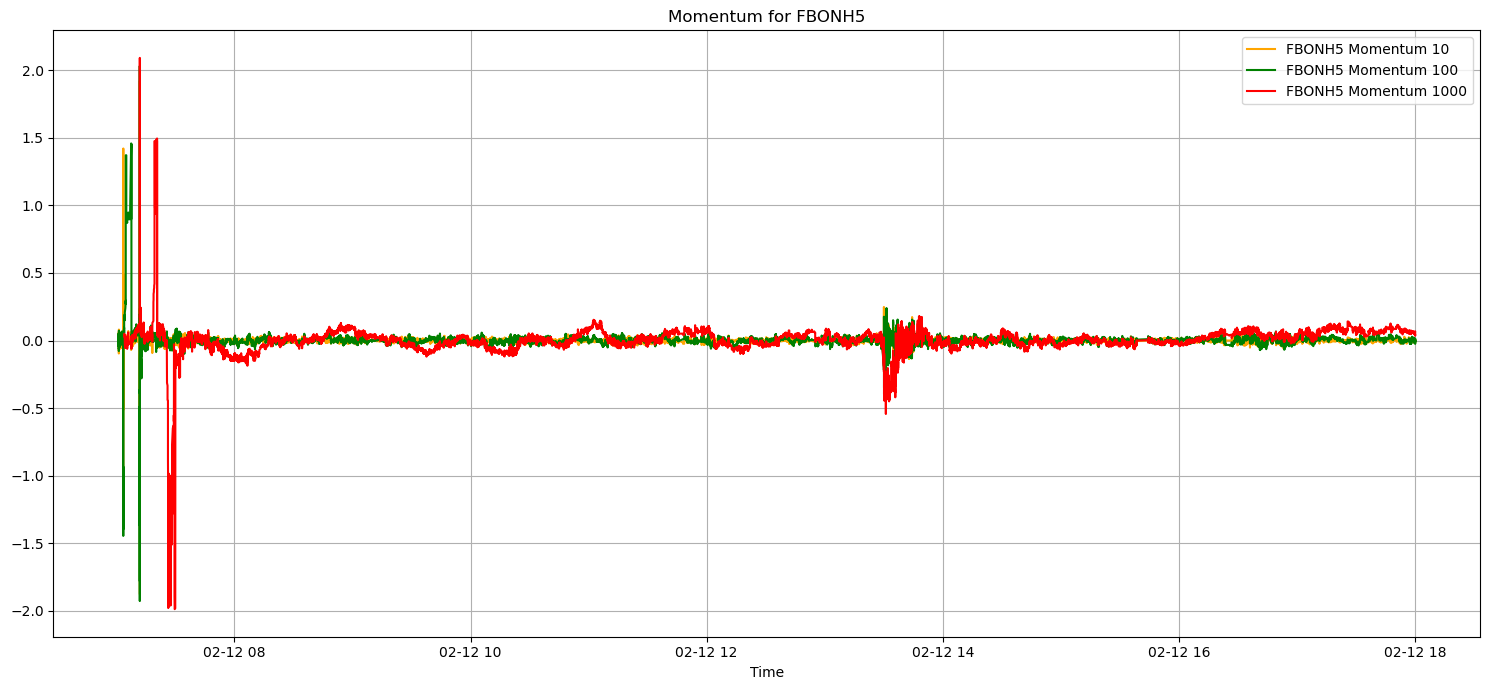

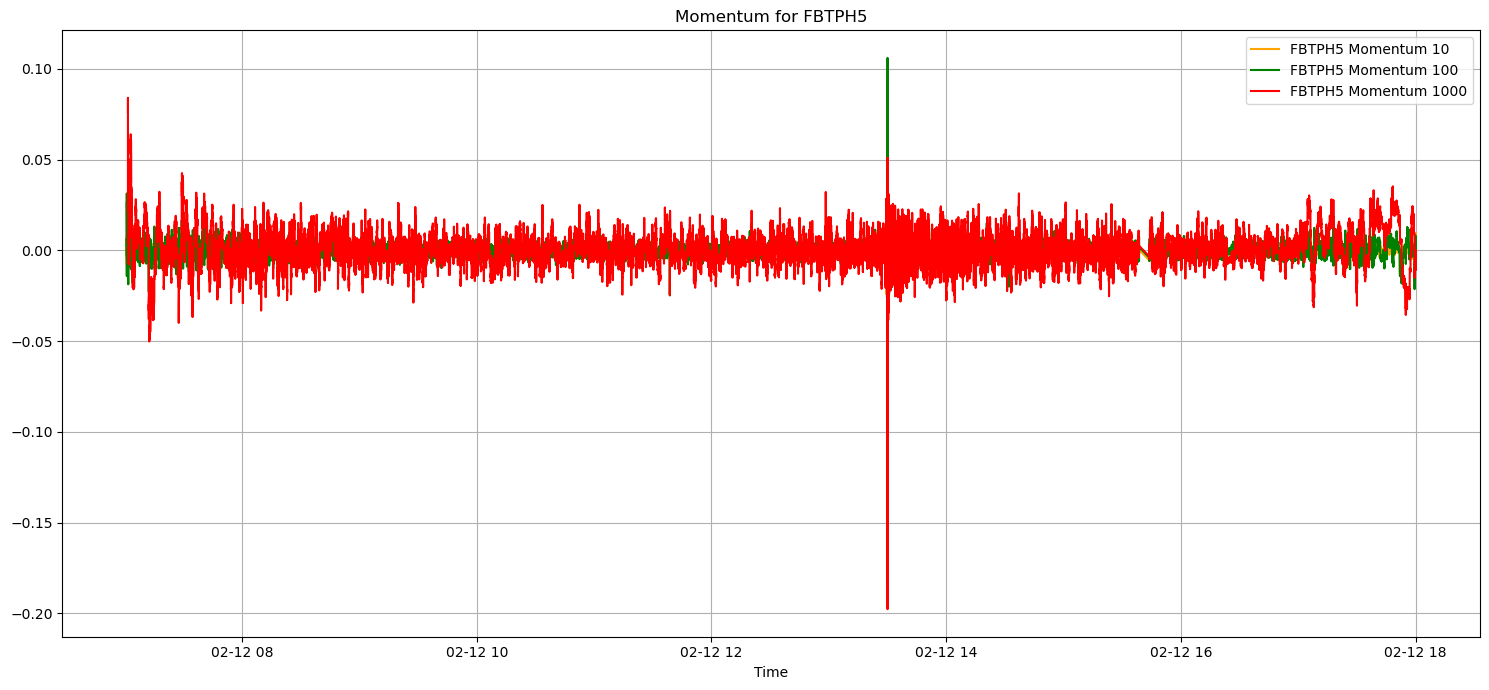

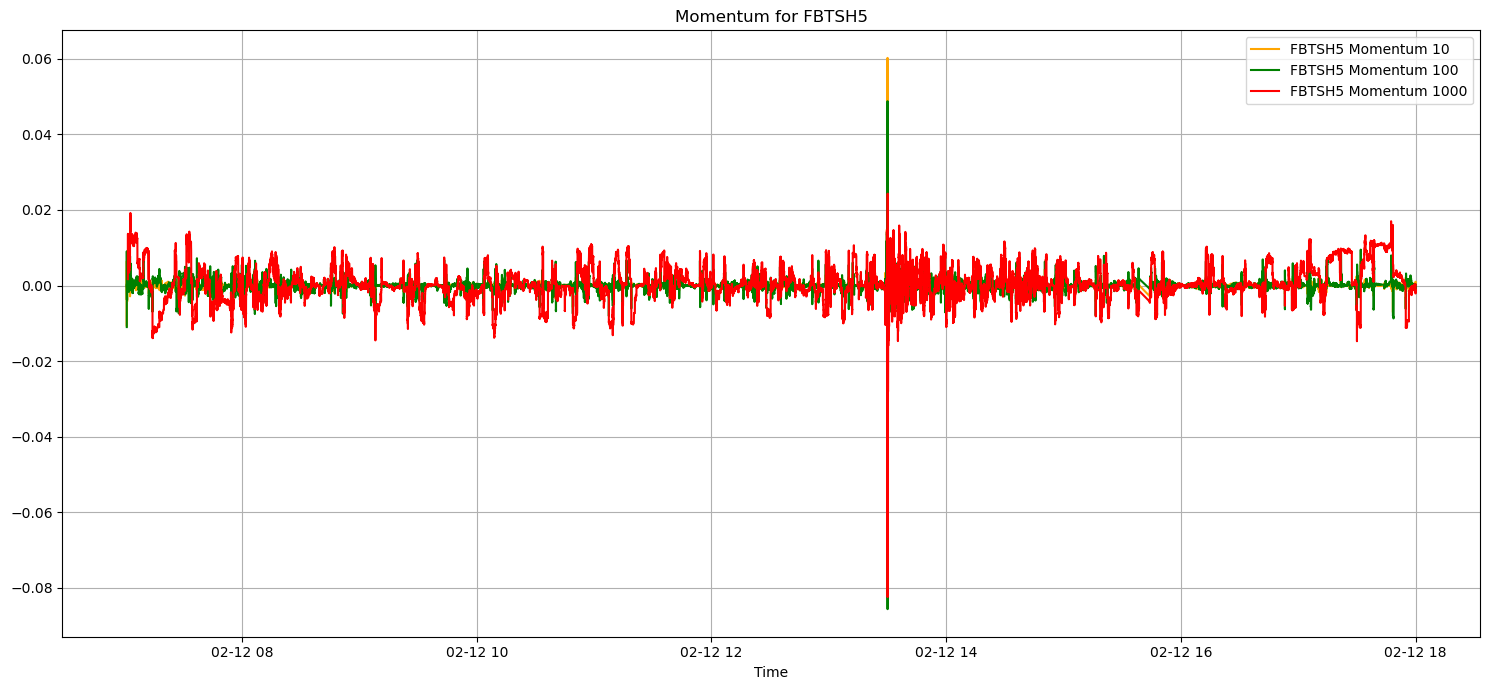

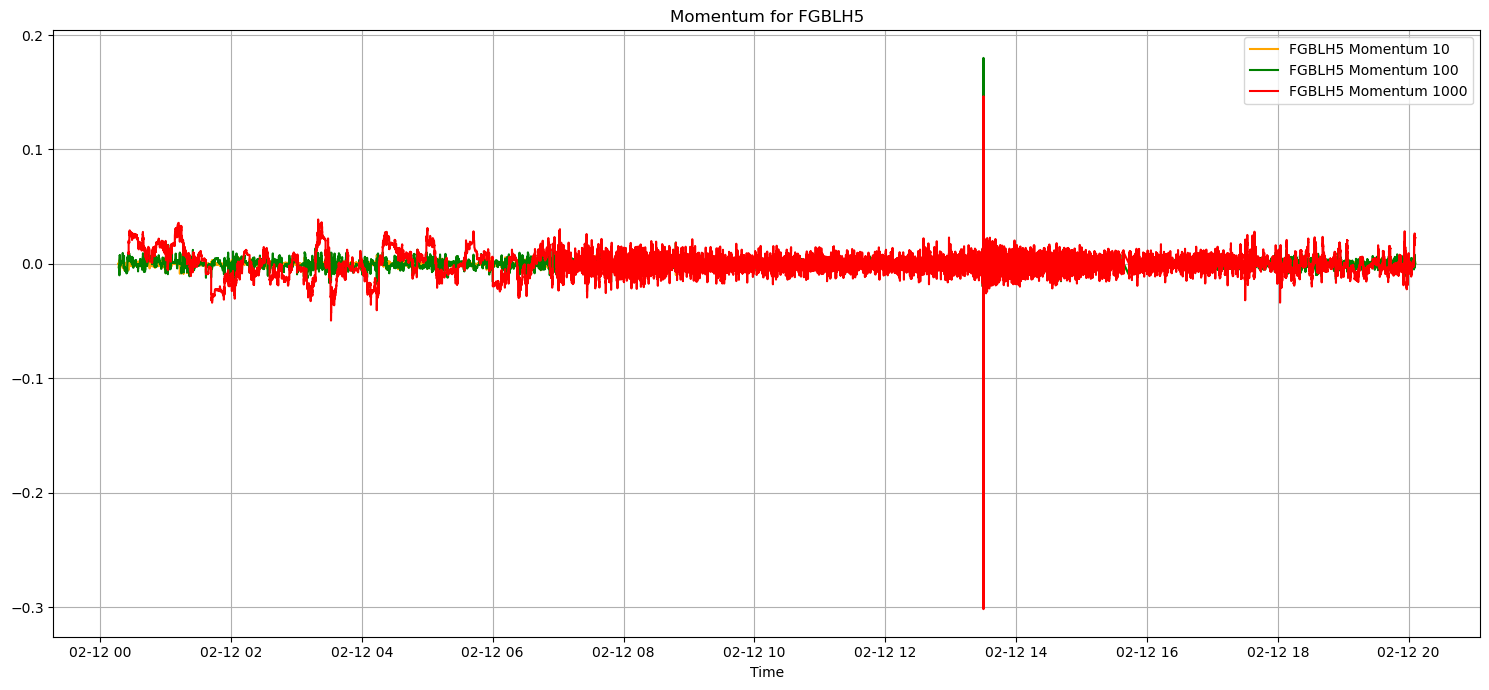

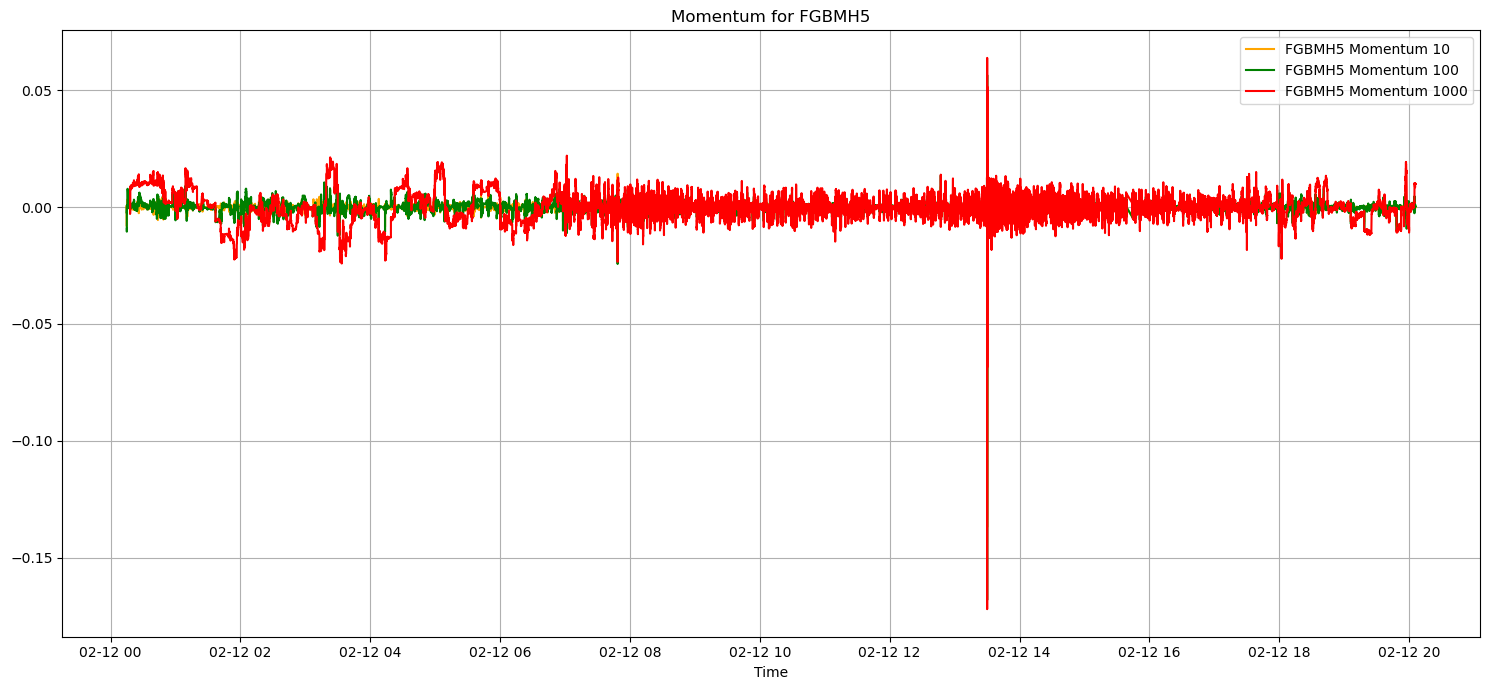

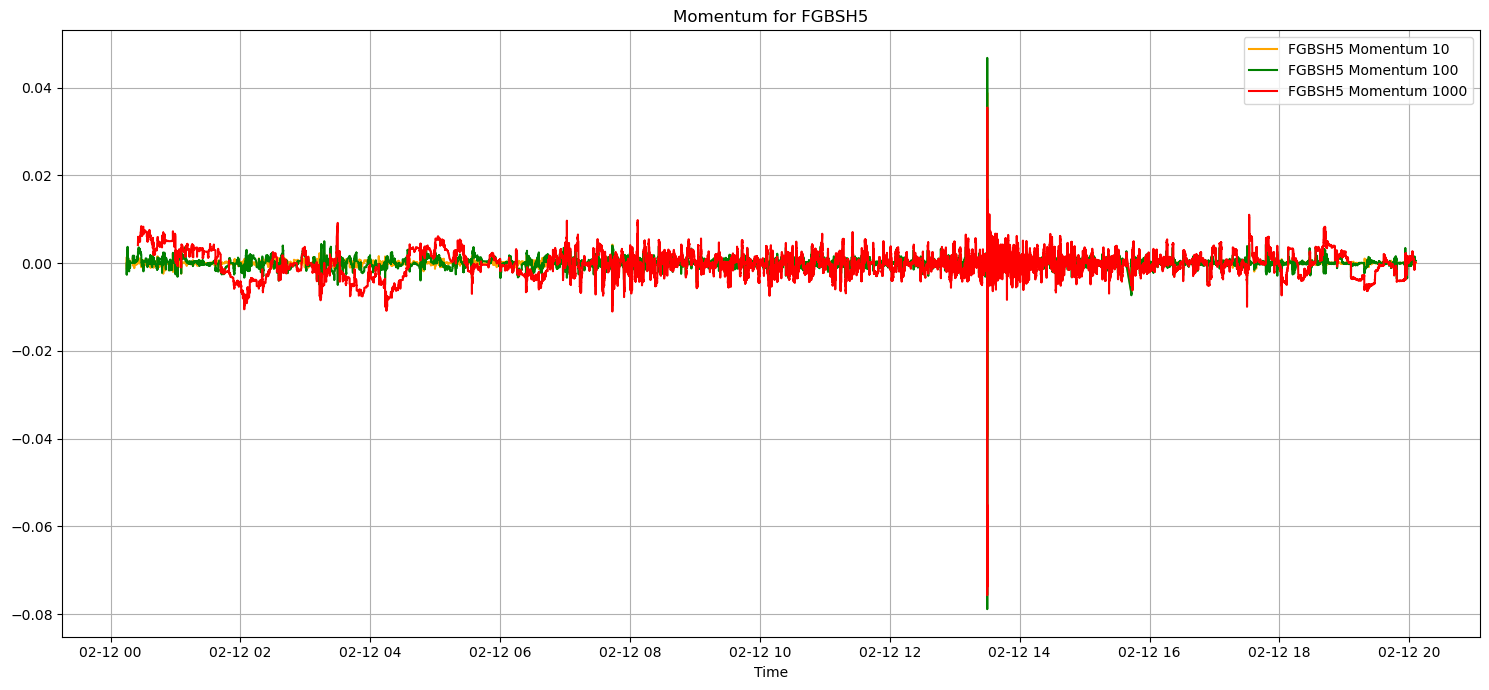

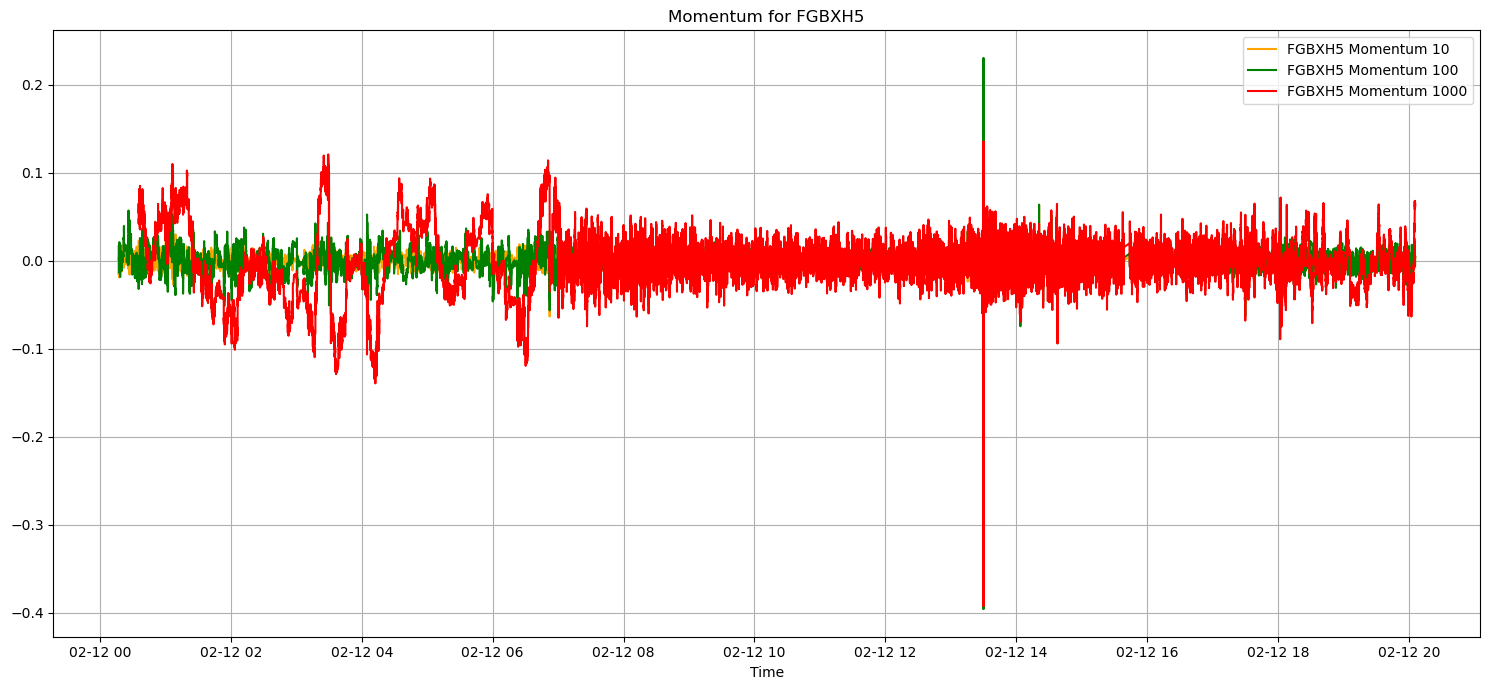

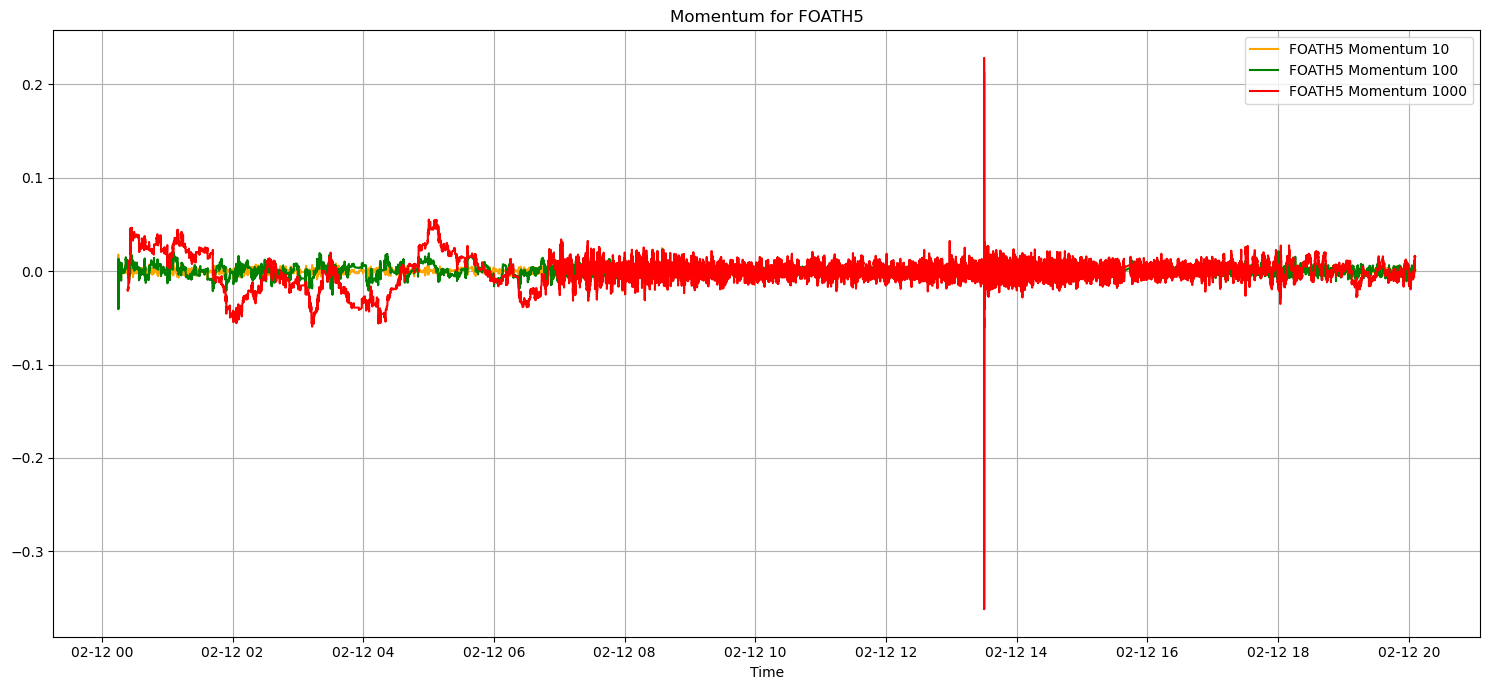

In [25]:
for sym, df_sym in sym_dfs.items():
    plt.figure(figsize=(15, 7)) 

    # Calculate the momentum indicators
    plt.plot(df_sym['time'], df_sym['momentum_10'], label=f'{sym} Momentum 10', color='orange')
    plt.plot(df_sym['time'], df_sym['momentum_100'], label=f'{sym} Momentum 100', color='green')
    plt.plot(df_sym['time'], df_sym['momentum_1000'], label=f'{sym} Momentum 1000', color='red')

    plt.title(f'Momentum for {sym}')
    plt.xlabel('Time')
    #plt.ylabel('Price')
    plt.legend()
    plt.grid(True) 
    plt.tight_layout()
    plt.show()

### OFI

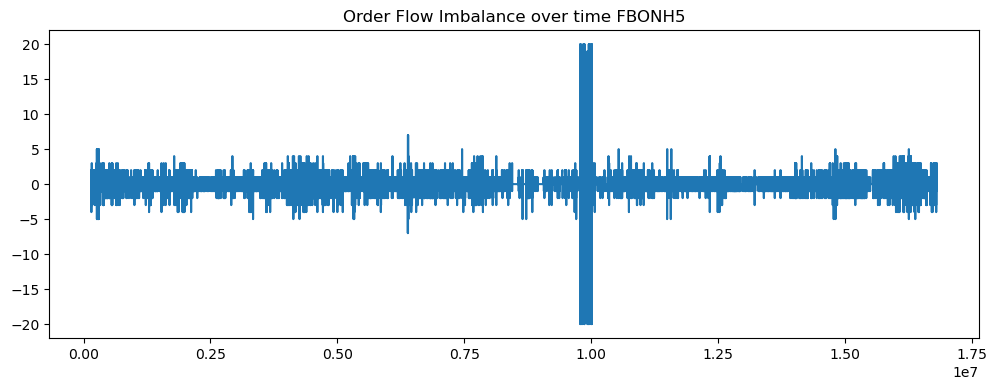

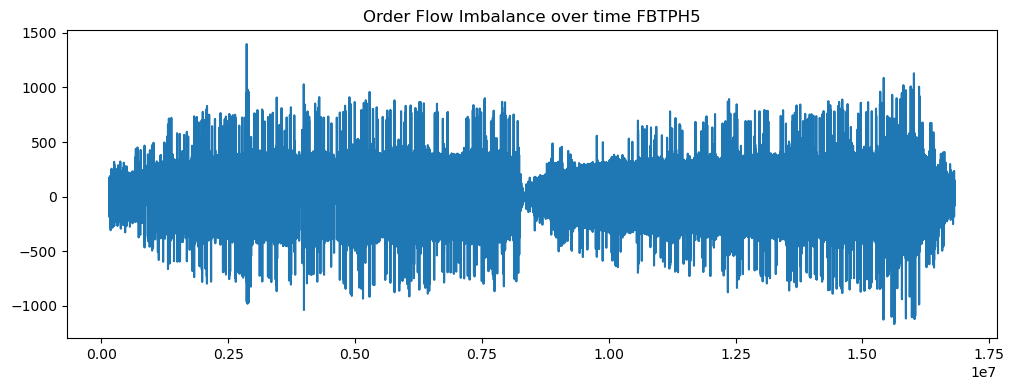

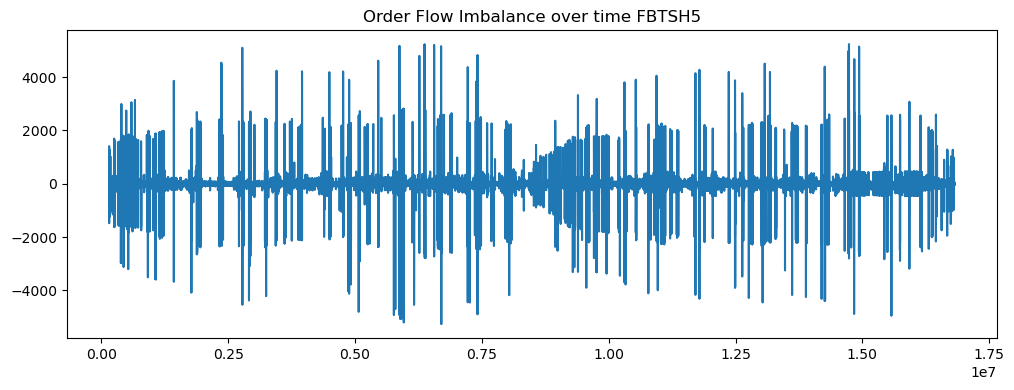

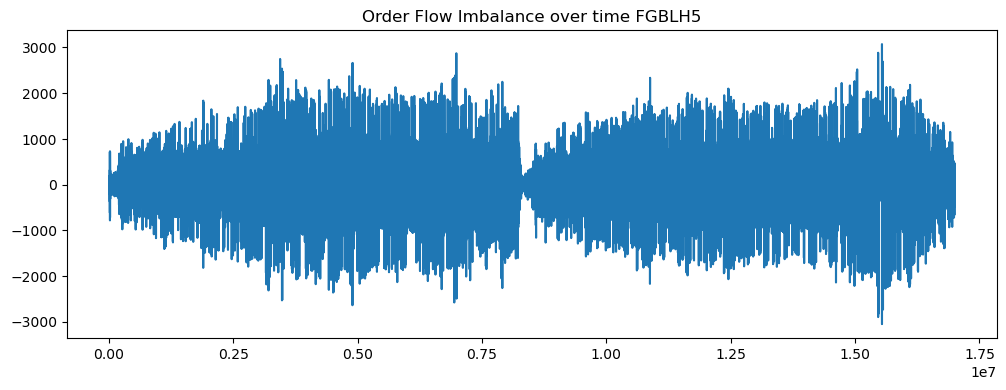

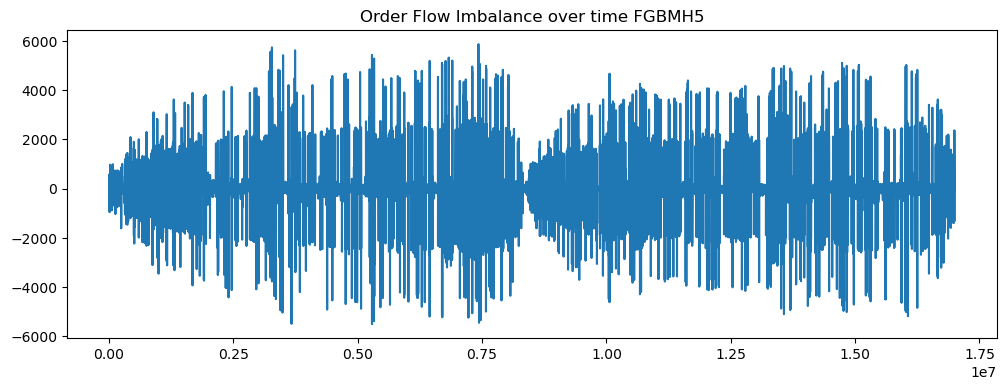

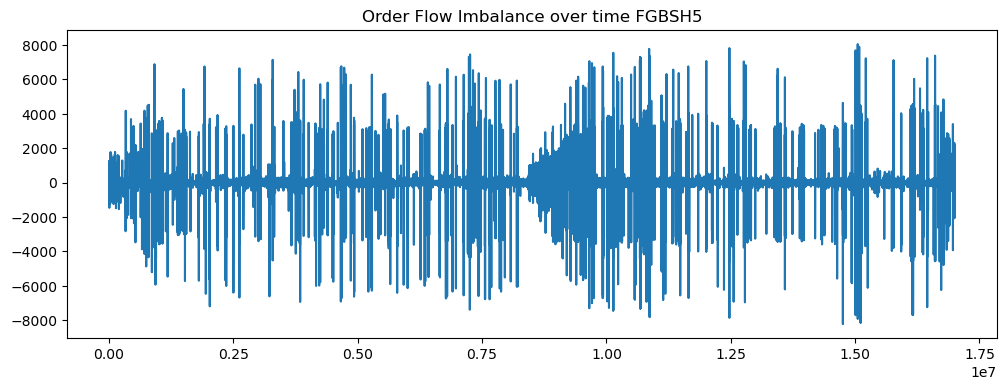

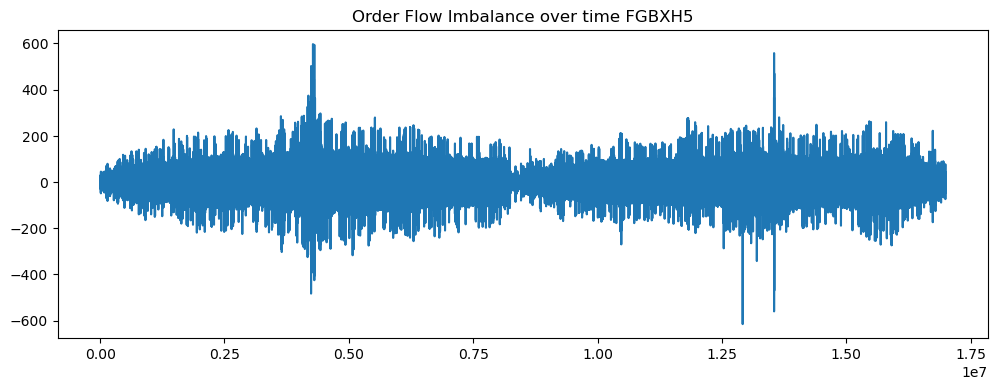

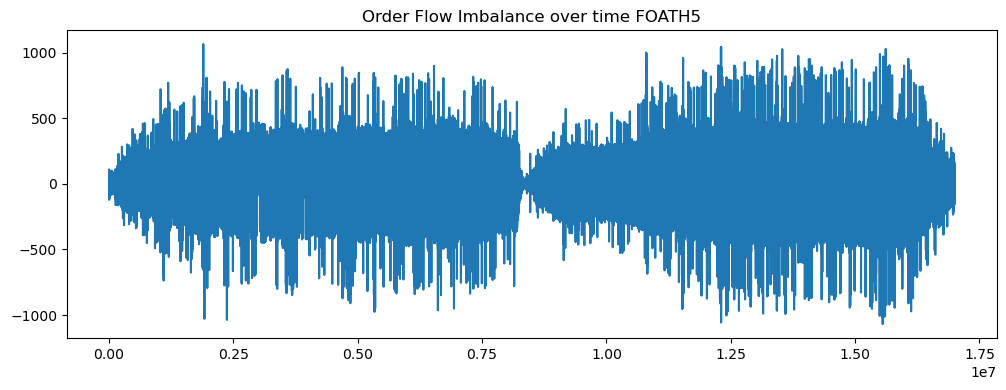

In [26]:
for sym, df_sym in sym_dfs.items():
    plt.figure(figsize=(15, 7)) 
    df_sym["ofi"].plot(title=f"Order Flow Imbalance over time {sym}", figsize=(12, 4))
    plt.show()

### Returns

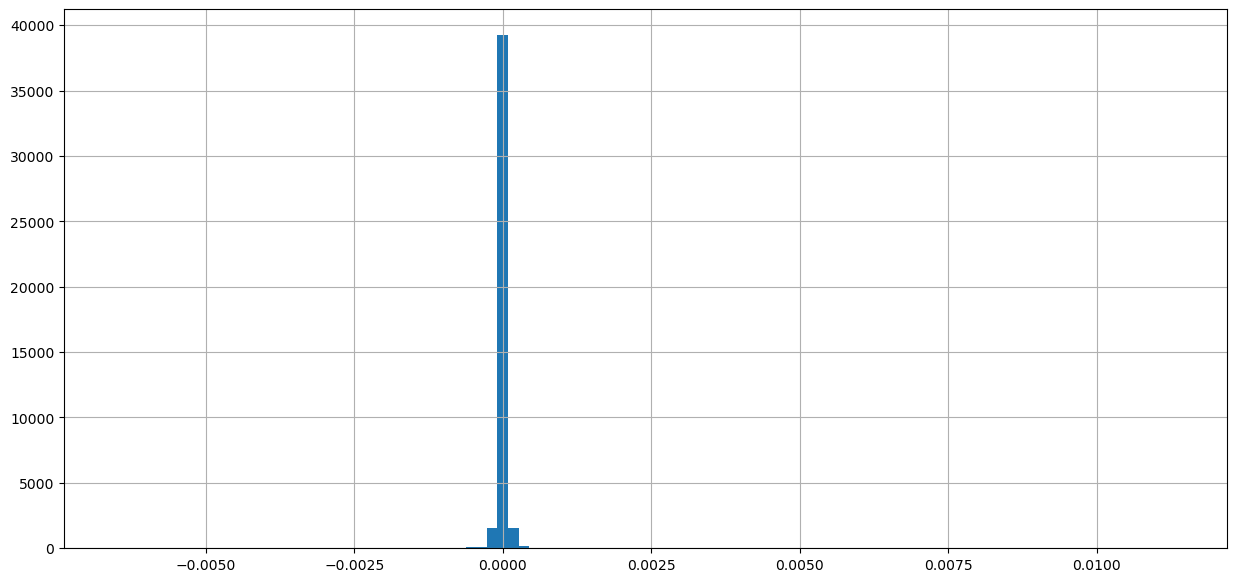

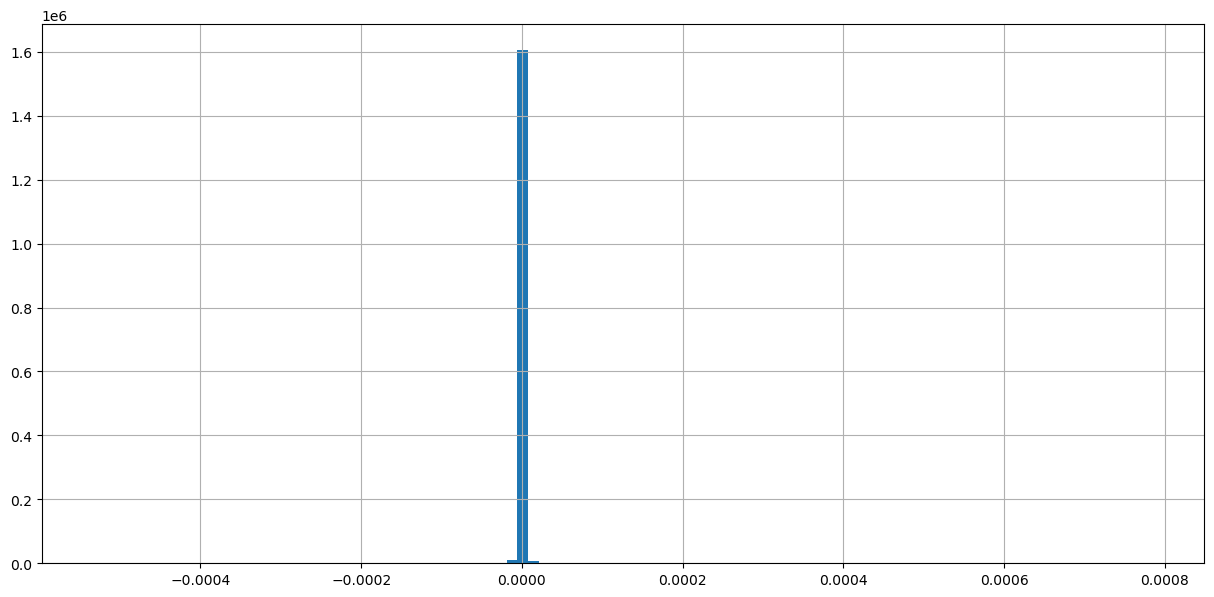

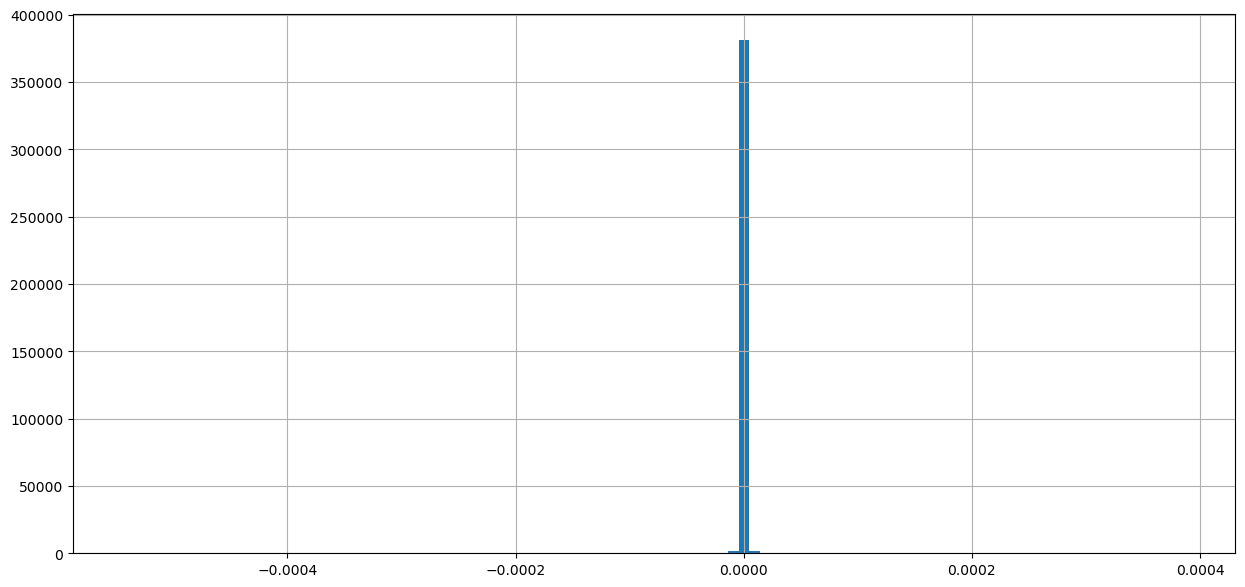

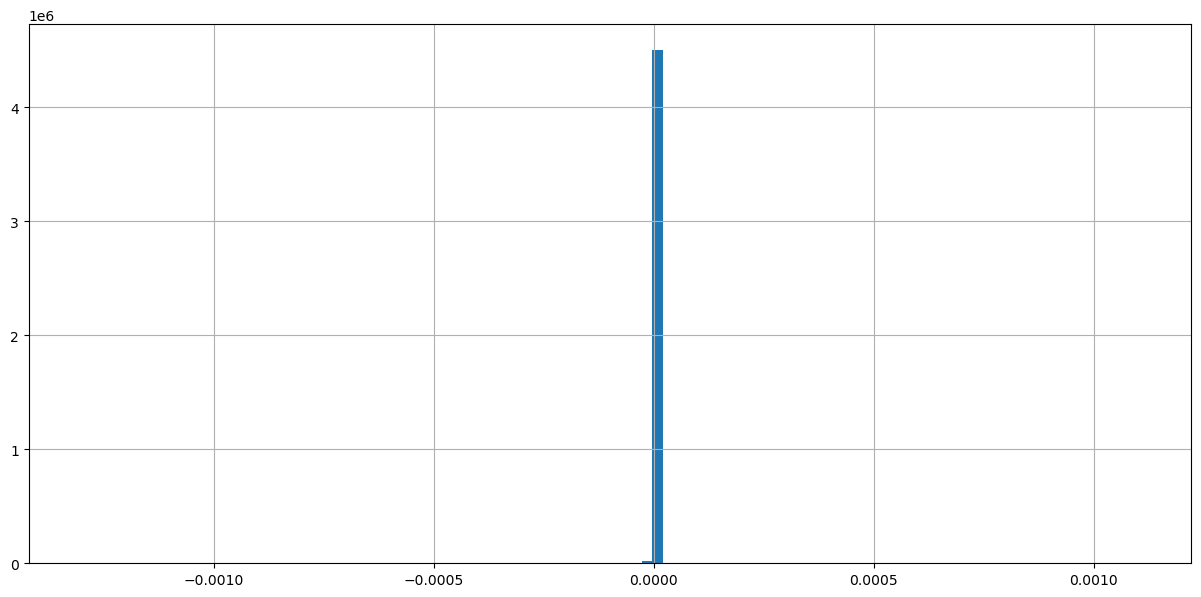

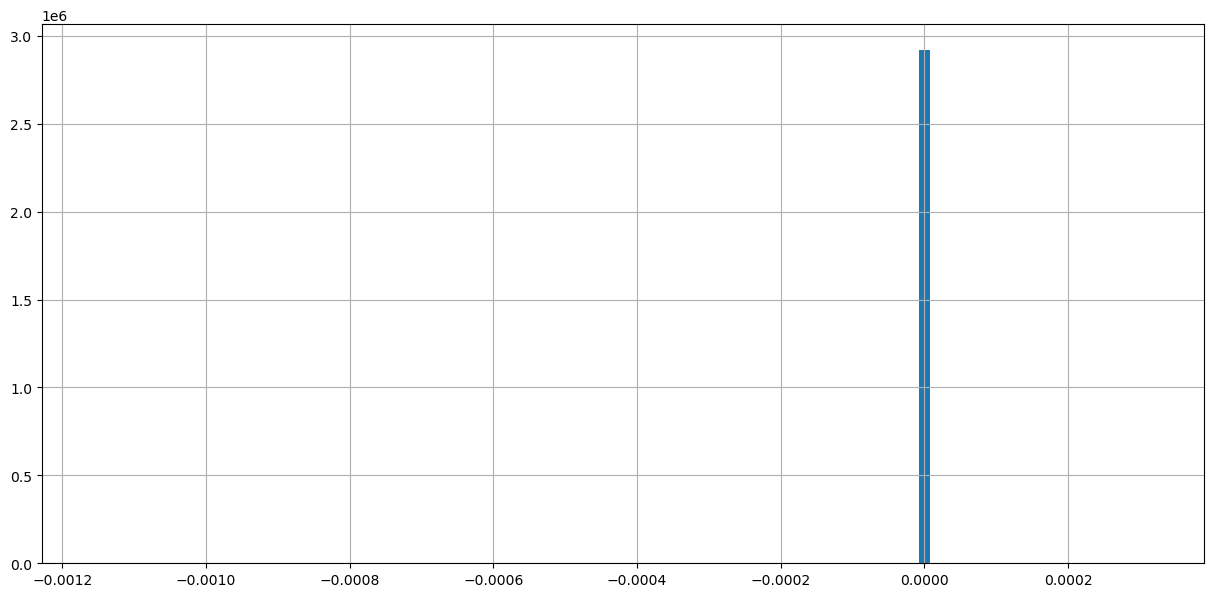

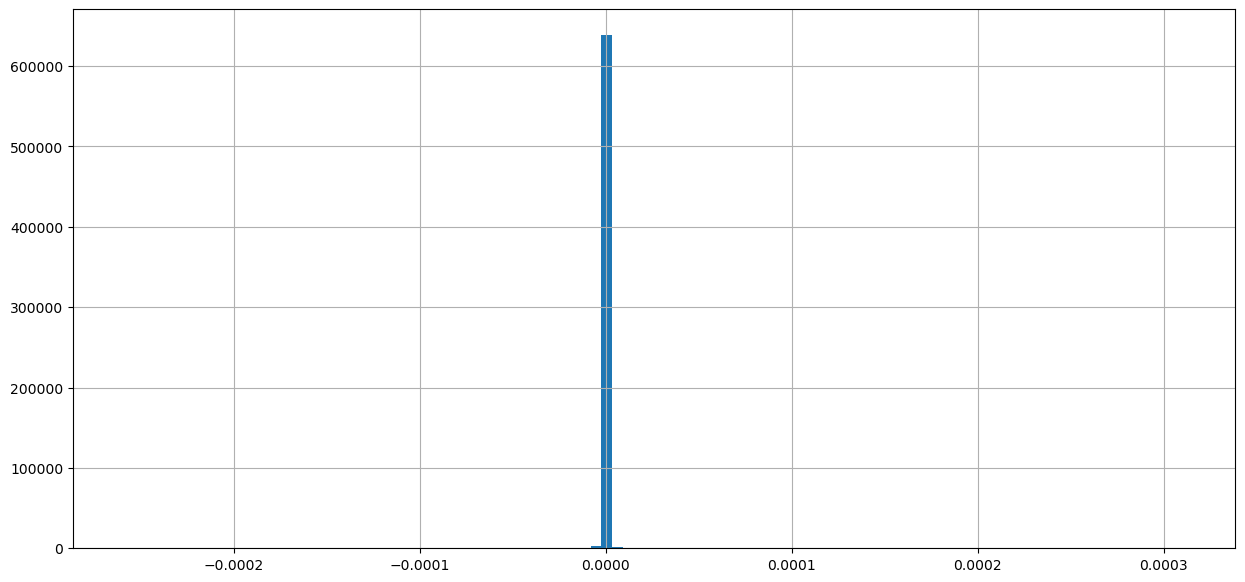

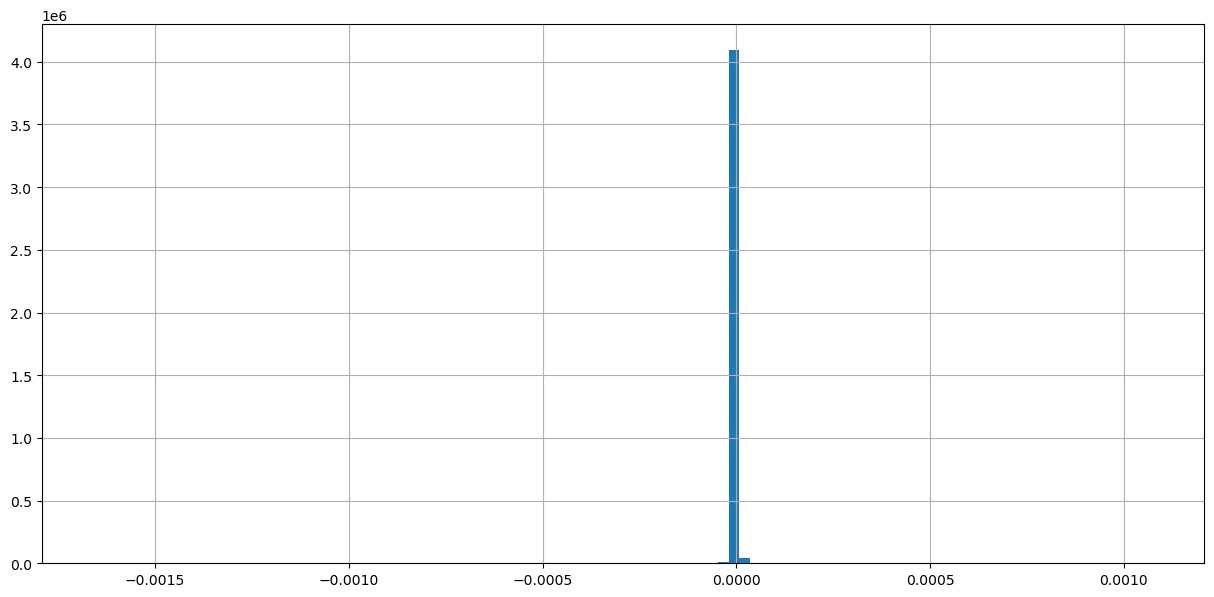

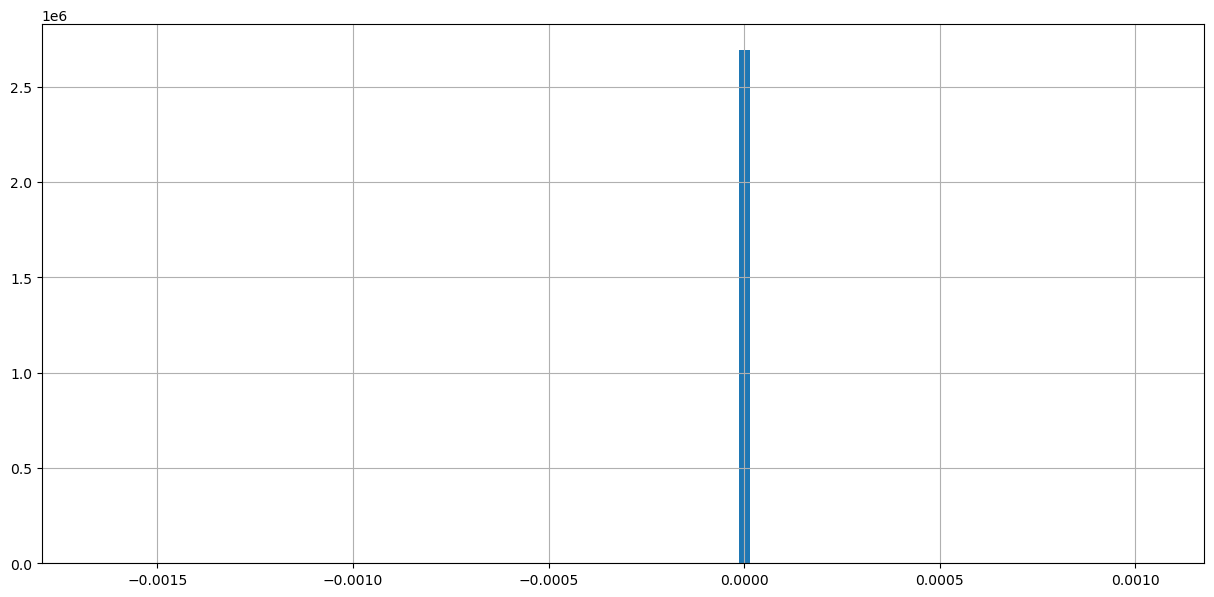

In [27]:
for sym, df_sym in sym_dfs.items():
    plt.figure(figsize=(15, 7))
    sym_dfs[sym]["return_1"].hist(bins=100)
    plt.show()

<Axes: >

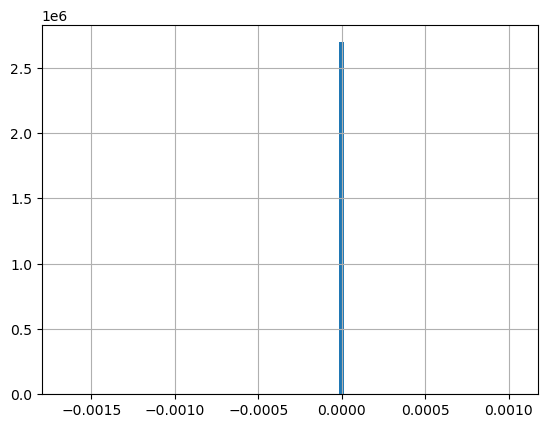

In [29]:
sym_dfs['FOATH5']["log_return_1"].hist(bins=100)

### RSI – Relative Strength Index

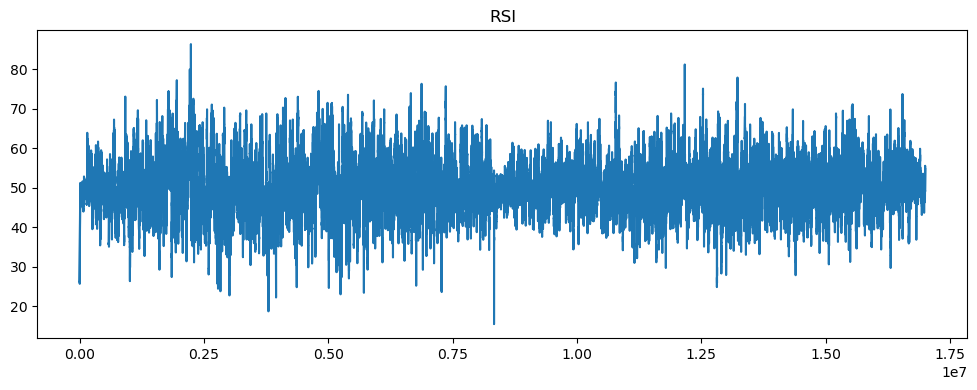

In [43]:
sym_dfs['FOATH5']["rsi_1000"].plot(title="RSI", figsize=(12, 4))
plt.show()


rsi_signal_100
 0    42791
 1      101
-1       13
Name: count, dtype: int64


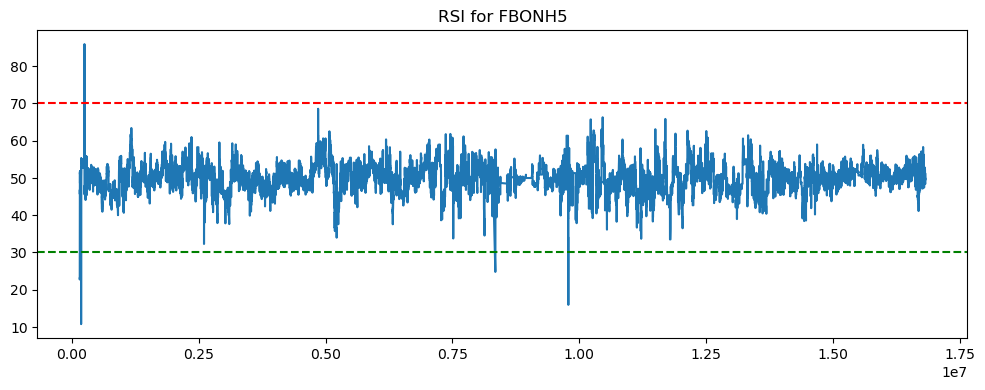

rsi_signal_100
 0    1354626
-1     139224
 1     130257
Name: count, dtype: int64


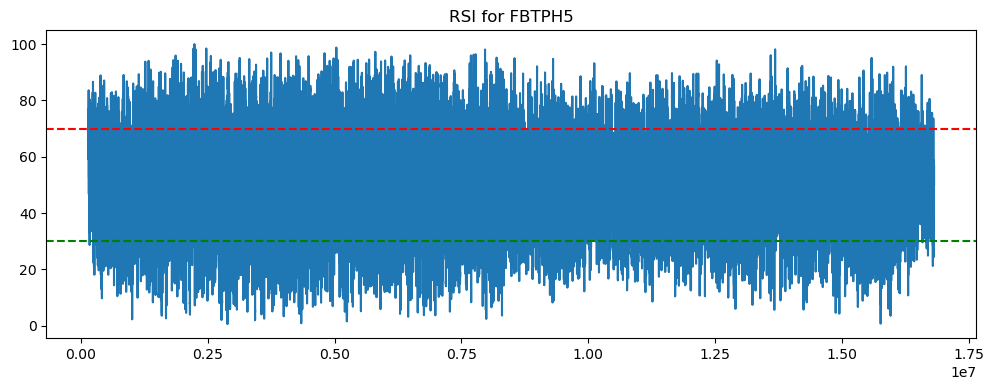

rsi_signal_100
 0    315729
-1     35154
 1     33693
Name: count, dtype: int64


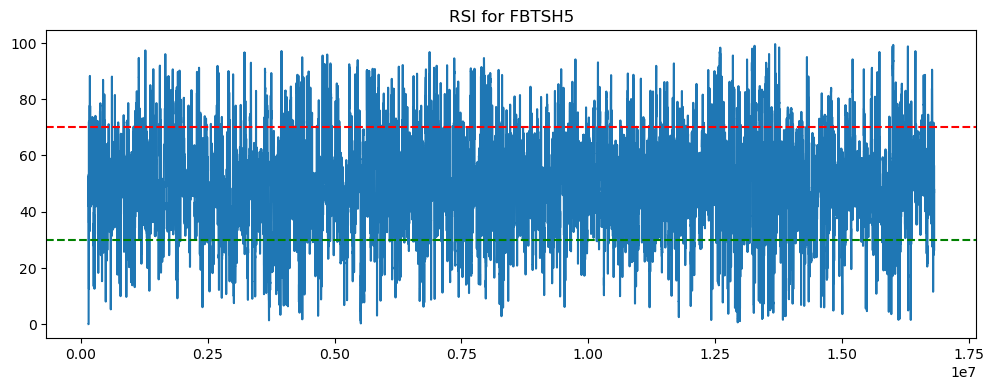

rsi_signal_100
 0    2912018
-1     817461
 1     794845
Name: count, dtype: int64


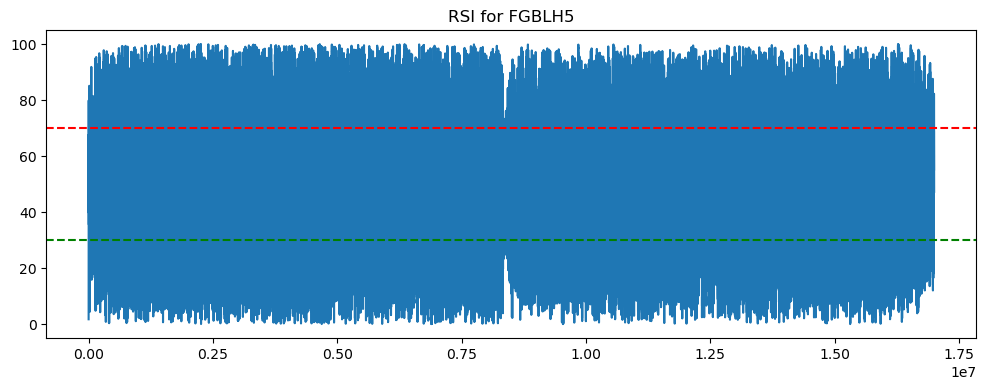

rsi_signal_100
 0    1808121
 1     567257
-1     548744
Name: count, dtype: int64


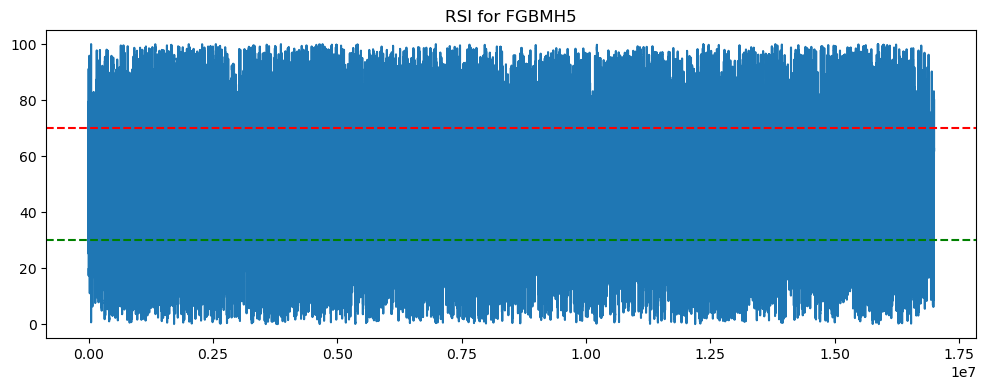

rsi_signal_100
 0    527901
 1     59103
-1     56460
Name: count, dtype: int64


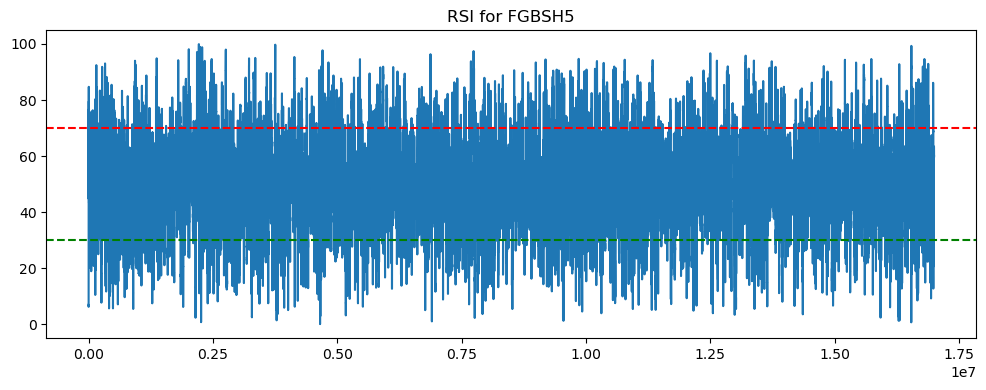

rsi_signal_100
 0    3071815
-1     551302
 1     523527
Name: count, dtype: int64


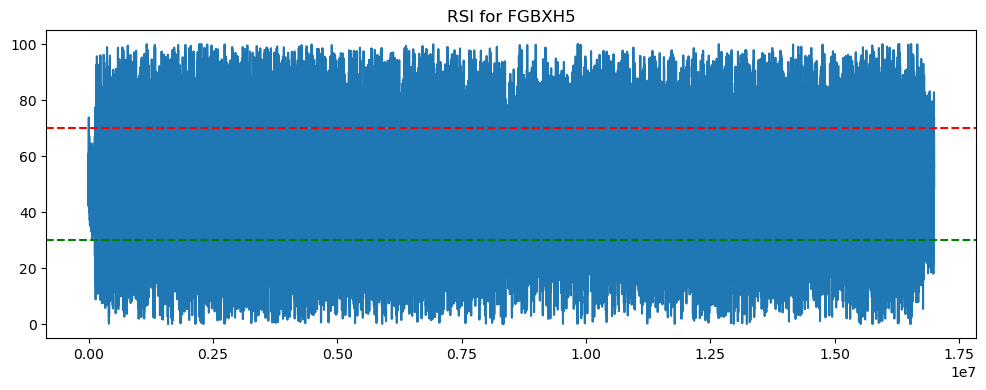

rsi_signal_100
 0    1934784
-1     385738
 1     379895
Name: count, dtype: int64


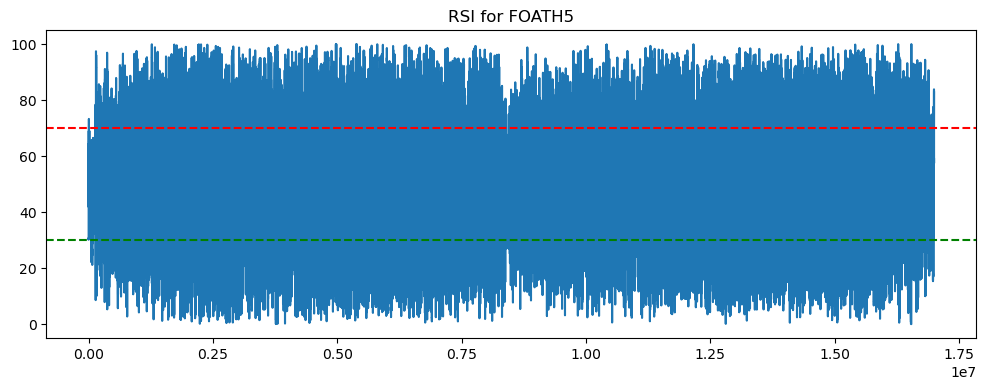

In [50]:
index = 100

for sym, df_sym in sym_dfs.items():
    print(df_sym[f'rsi_signal_{index}'].value_counts())
    plt.figure(figsize=(15, 7))
    df_sym[f'rsi_{index}'].plot(title="RSI", figsize=(12, 4))
    plt.title(f"RSI for {sym}")
    plt.axhline(70, color='r', linestyle='--')
    plt.axhline(30, color='g', linestyle='--')
    plt.show()

### Bollinger Bands

bollinger_signal_20
 0    39355
 1     1780
-1     1770
Name: count, dtype: int64


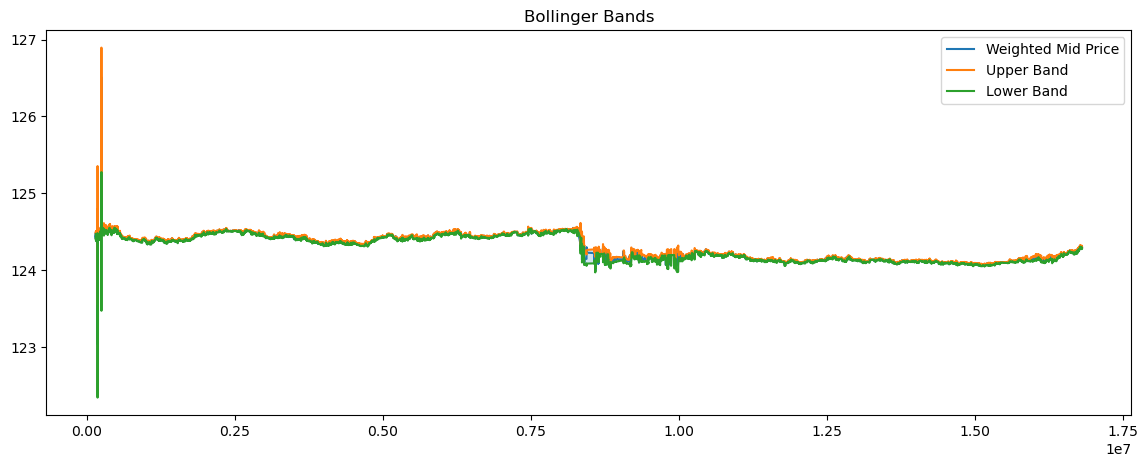

bollinger_signal_20
 0    1398842
 1     113112
-1     112153
Name: count, dtype: int64


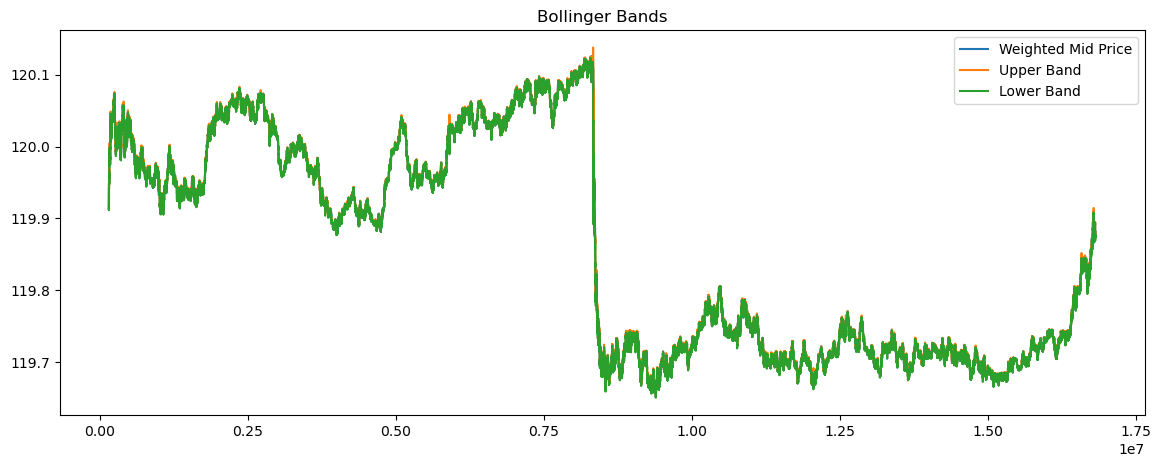

bollinger_signal_20
 0    336295
 1     24154
-1     24127
Name: count, dtype: int64


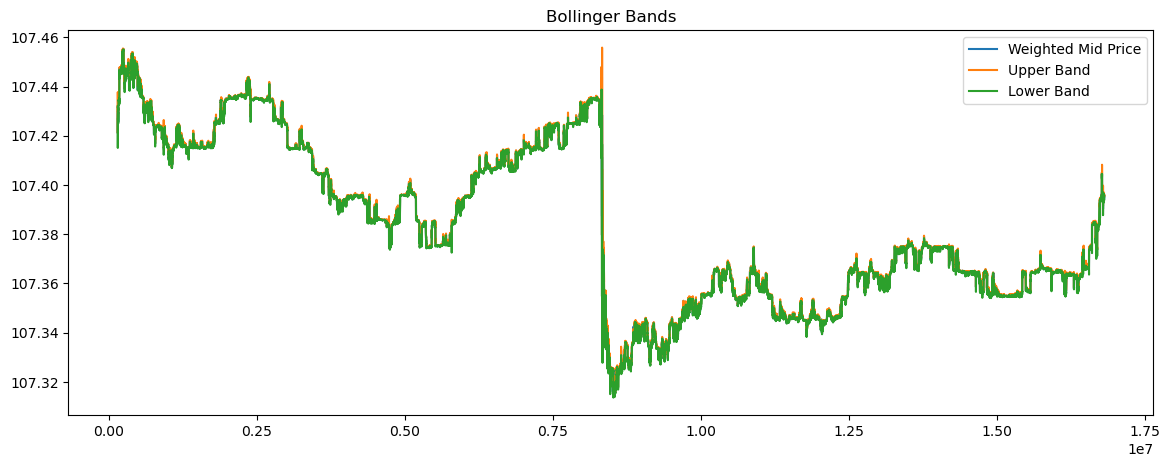

bollinger_signal_20
 0    3774244
-1     376178
 1     373902
Name: count, dtype: int64


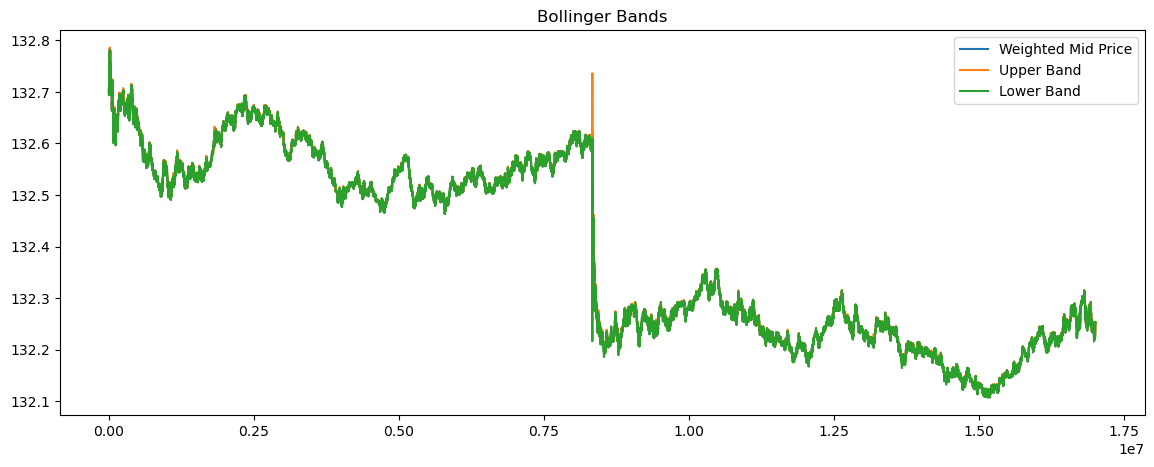

bollinger_signal_20
 0    2463101
 1     234869
-1     226152
Name: count, dtype: int64


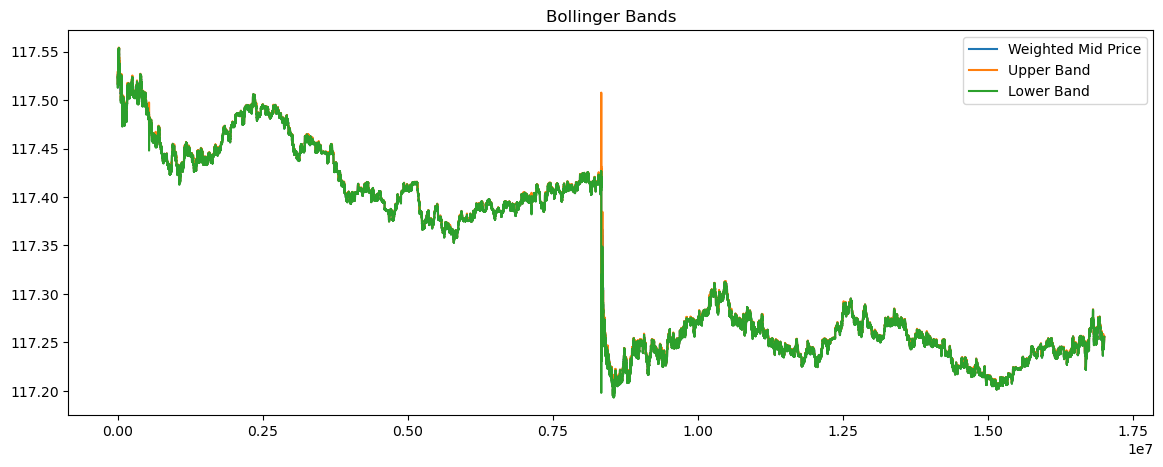

bollinger_signal_20
 0    554277
 1     44737
-1     44450
Name: count, dtype: int64


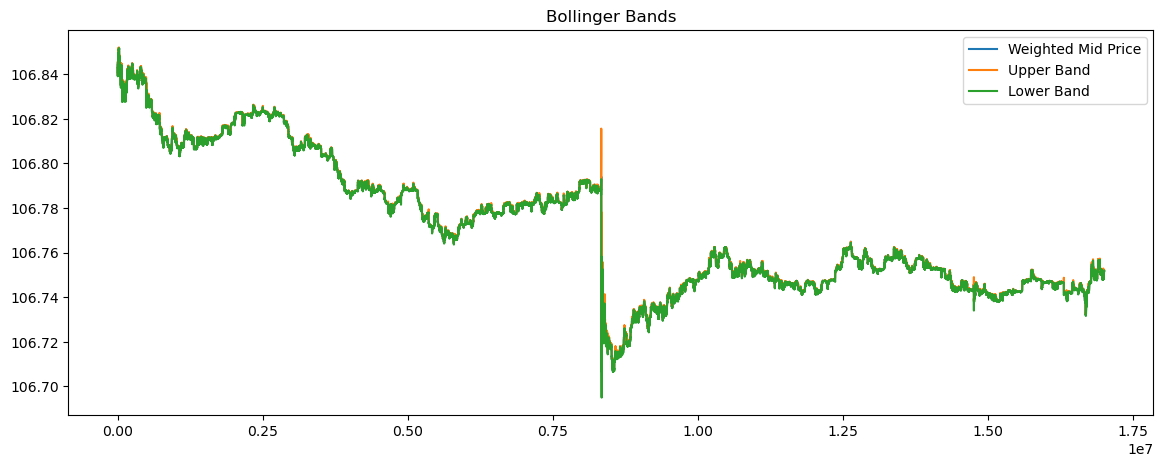

bollinger_signal_20
 0    3633320
-1     258755
 1     254569
Name: count, dtype: int64


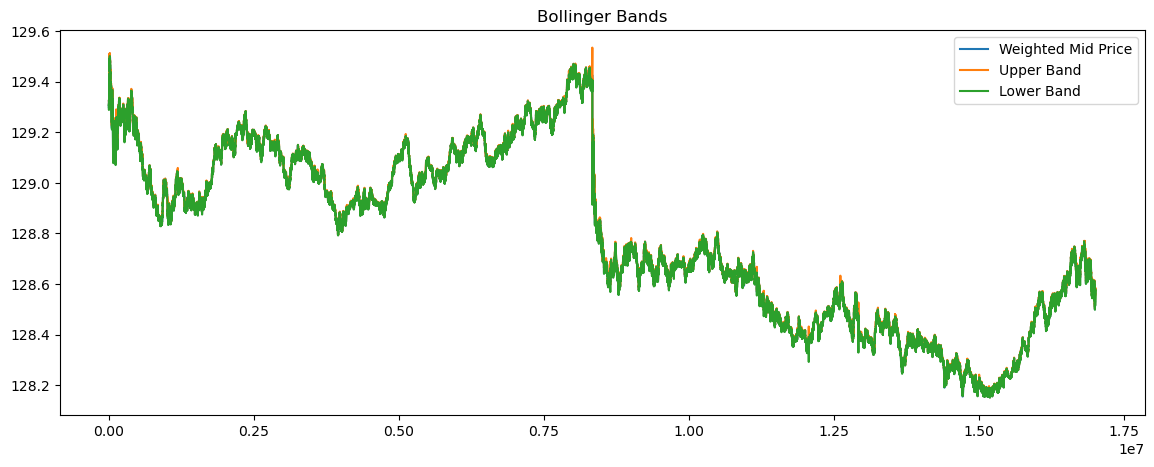

bollinger_signal_20
 0    2319566
-1     190633
 1     190218
Name: count, dtype: int64


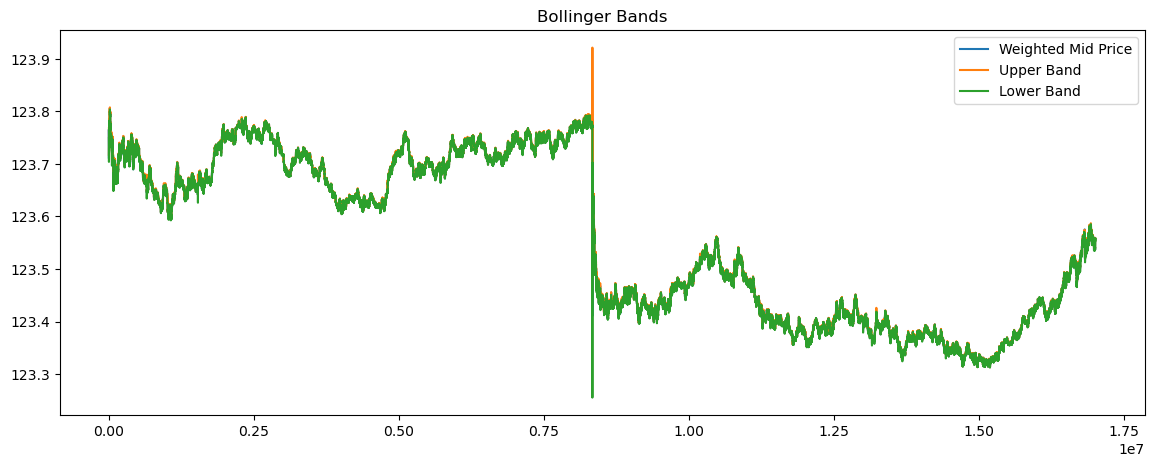

In [61]:
index = 20

for sym, df_sym in sym_dfs.items():

    print(df_sym[f"bollinger_signal_{index}"].value_counts())

    plt.figure(figsize=(14, 5))
    plt.plot(df_sym["weighted_mid_price"], label="Weighted Mid Price")
    plt.plot(df_sym[f"bollinger_upper_{index}"], label="Upper Band")
    plt.plot(df_sym[f"bollinger_lower_{index}"], label="Lower Band")
    plt.fill_between(df_sym.index, df_sym[f"bollinger_lower_{index}"], df_sym[f"bollinger_upper_{index}"], alpha=0.2)
    plt.legend()
    plt.title("Bollinger Bands")
    plt.show()